# Chat-annotation evaluation

Lean display notebook. Plot generation lives in `analysis/chat_annotation/plot_*.py`.
Run `make_all_figs.py` first to (re)build the figures, then refresh this notebook.

```
./flamenco-env/bin/python analysis/chat_annotation/make_all_figs.py
```

Headline counts:

In [7]:
import sys
from pathlib import Path

HERE = Path.cwd()
if HERE.name != 'chat_annotation':
    HERE = Path('analysis/chat_annotation')
sys.path.insert(0, str(HERE))

from IPython.display import Image, display, Markdown
from common import load_articles, load_codes, load_possible, load_basis, FIGS_DIR

arts = load_articles()
codes = load_codes()
possible = load_possible()
basis = load_basis()

summary = arts.groupby('periodical_label').agg(
    n_articles=('article_id','nunique'),
    n_codes=('n_codes','sum'),
    n_possible=('n_possible','sum'),
    no_relevant=('no_relevant_discourse','sum'),
    insufficient=('insufficient_context','sum'),
    mean_codes_per_article=('n_codes','mean'),
).round(2)
summary

,n_articles,n_codes,n_possible,no_relevant,insufficient,mean_codes_per_article
periodical_label,,,,,,
Candil,1768,4715,2389,197,47,2.66
Jaleo,1279,2949,1889,169,36,2.31


## 1. Basic statistics

**plot_01_coverage** -- annotation coverage decisions per periodical

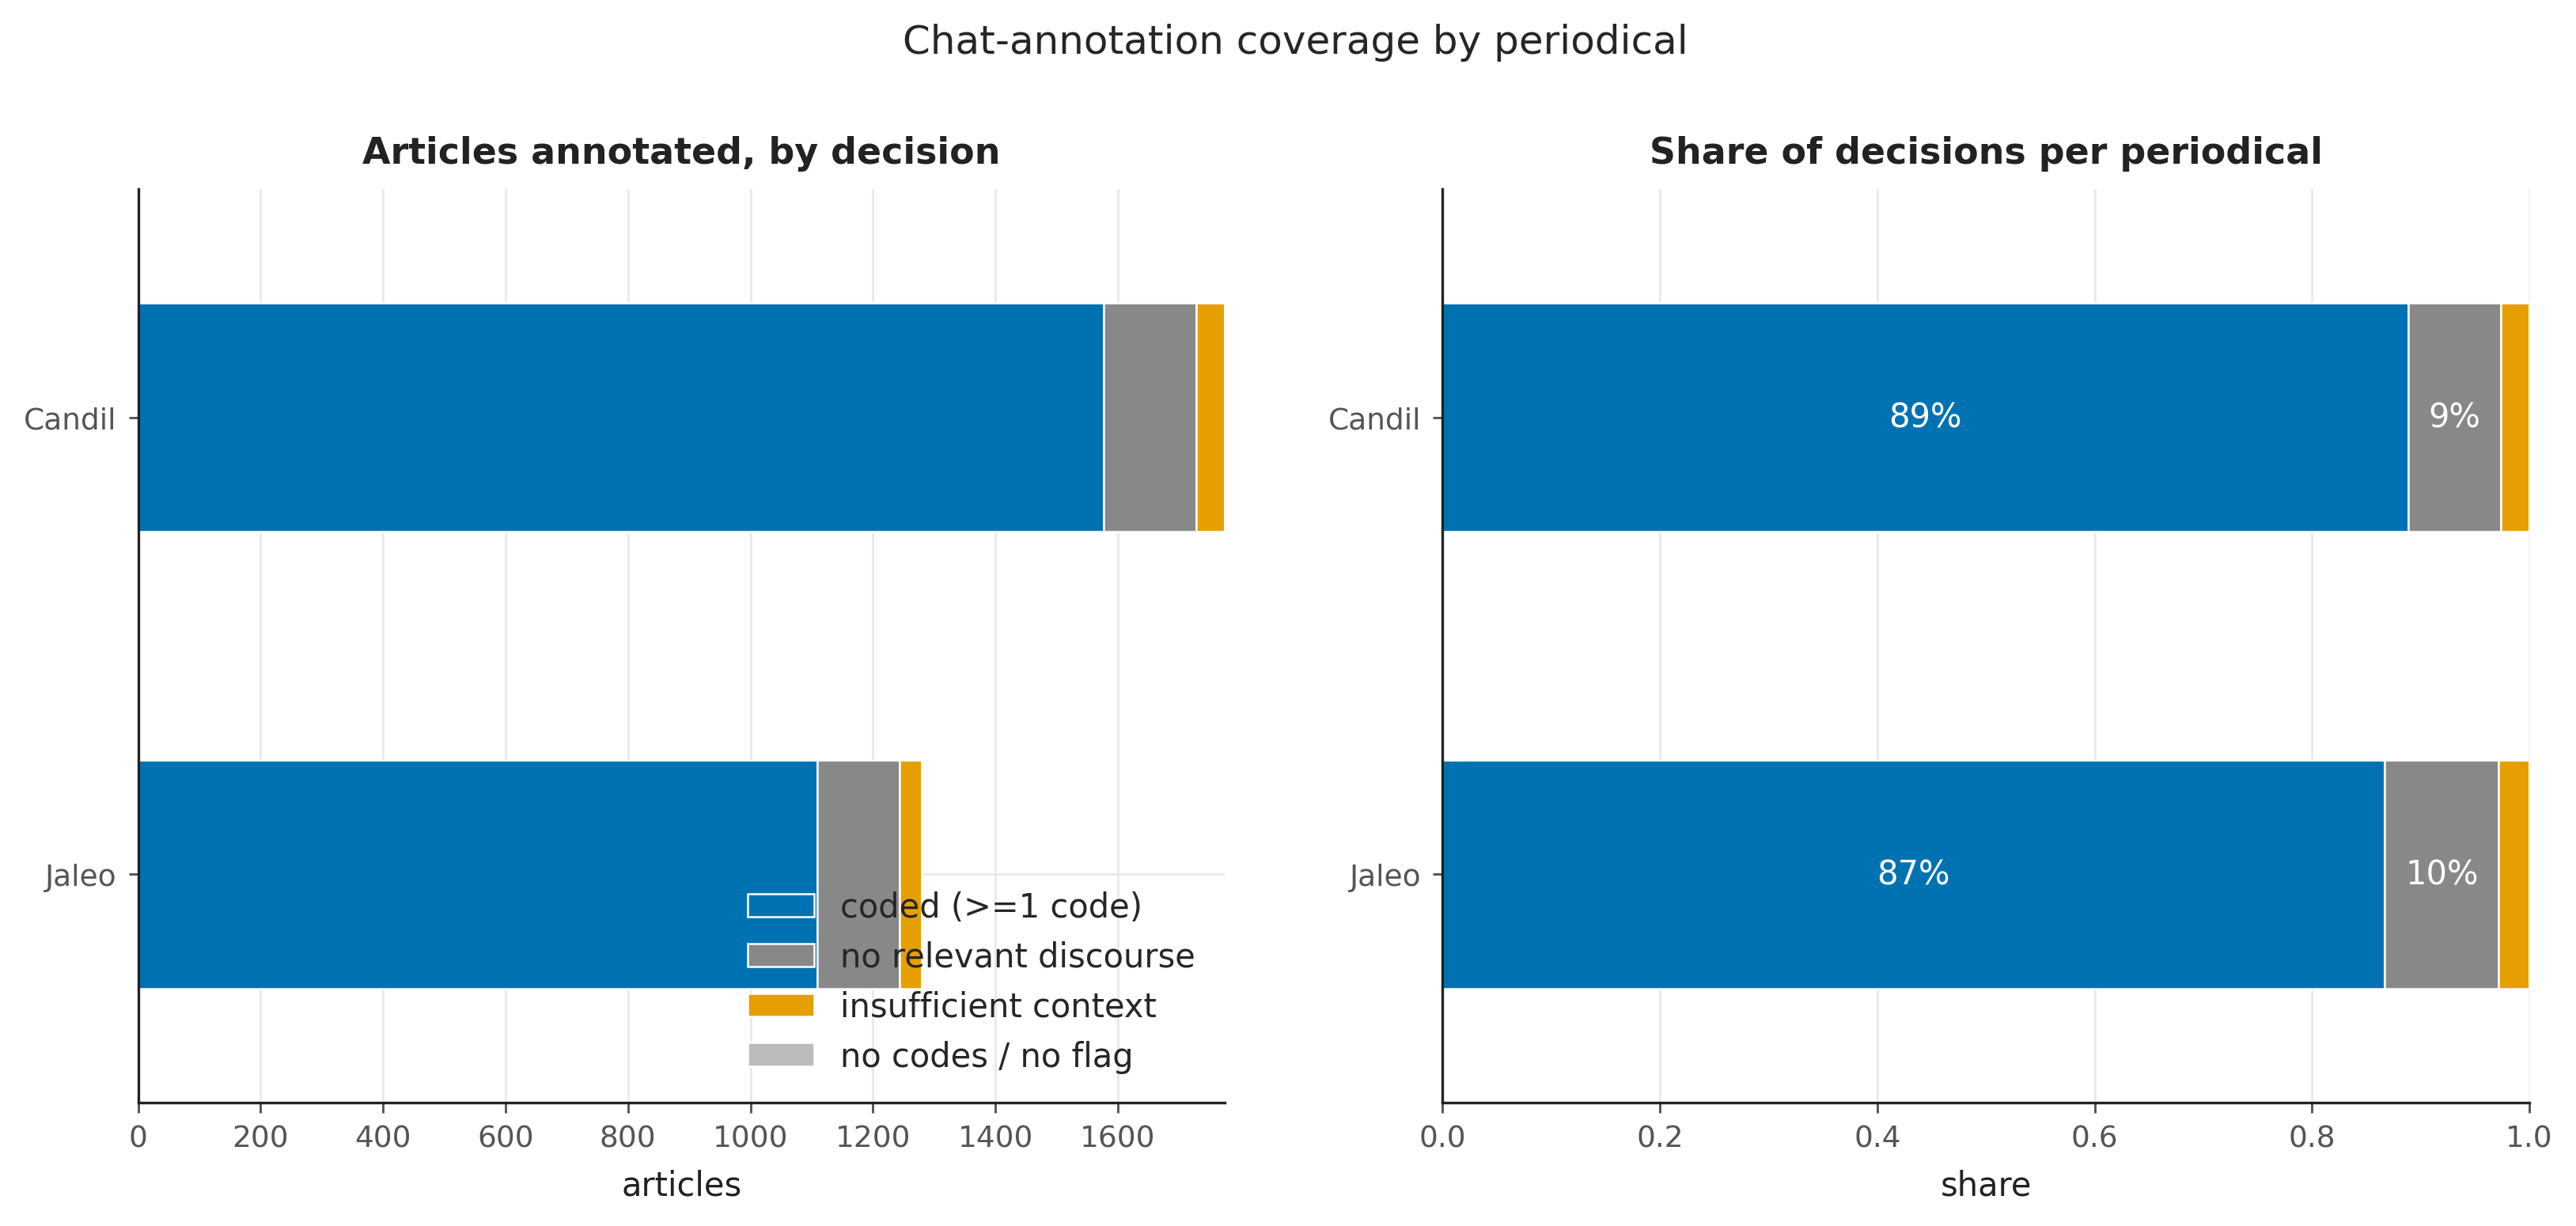

**plot_02_codes_per_article** -- codes-per-article distribution

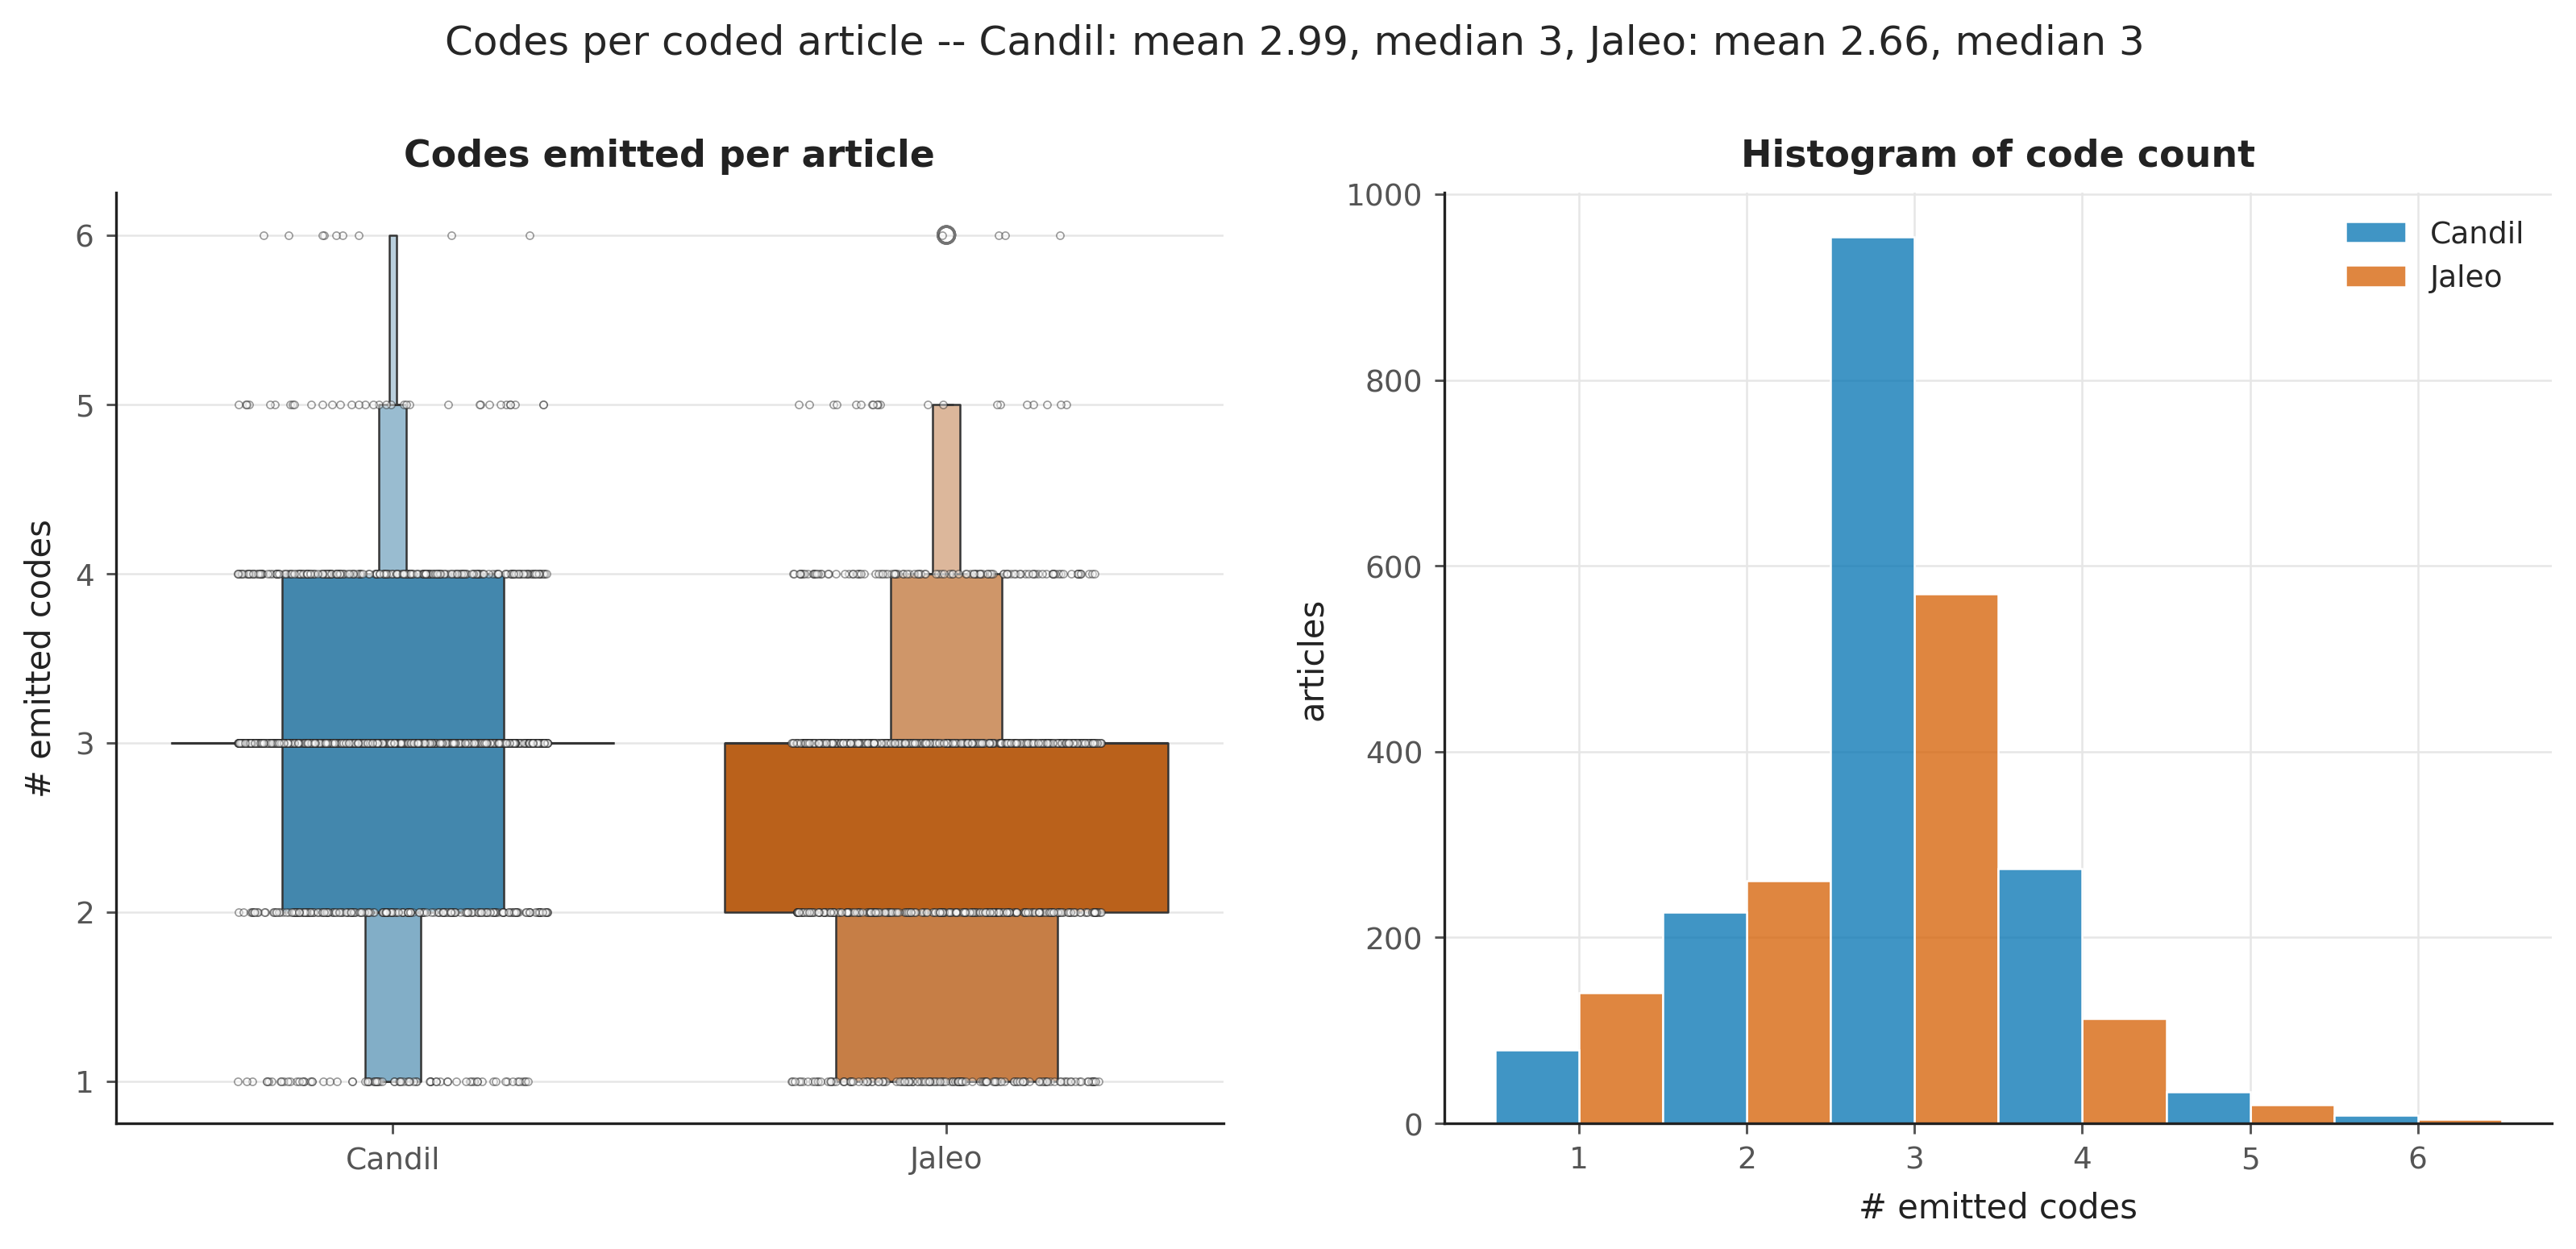

**plot_03_family_emission** -- family-level emission profile

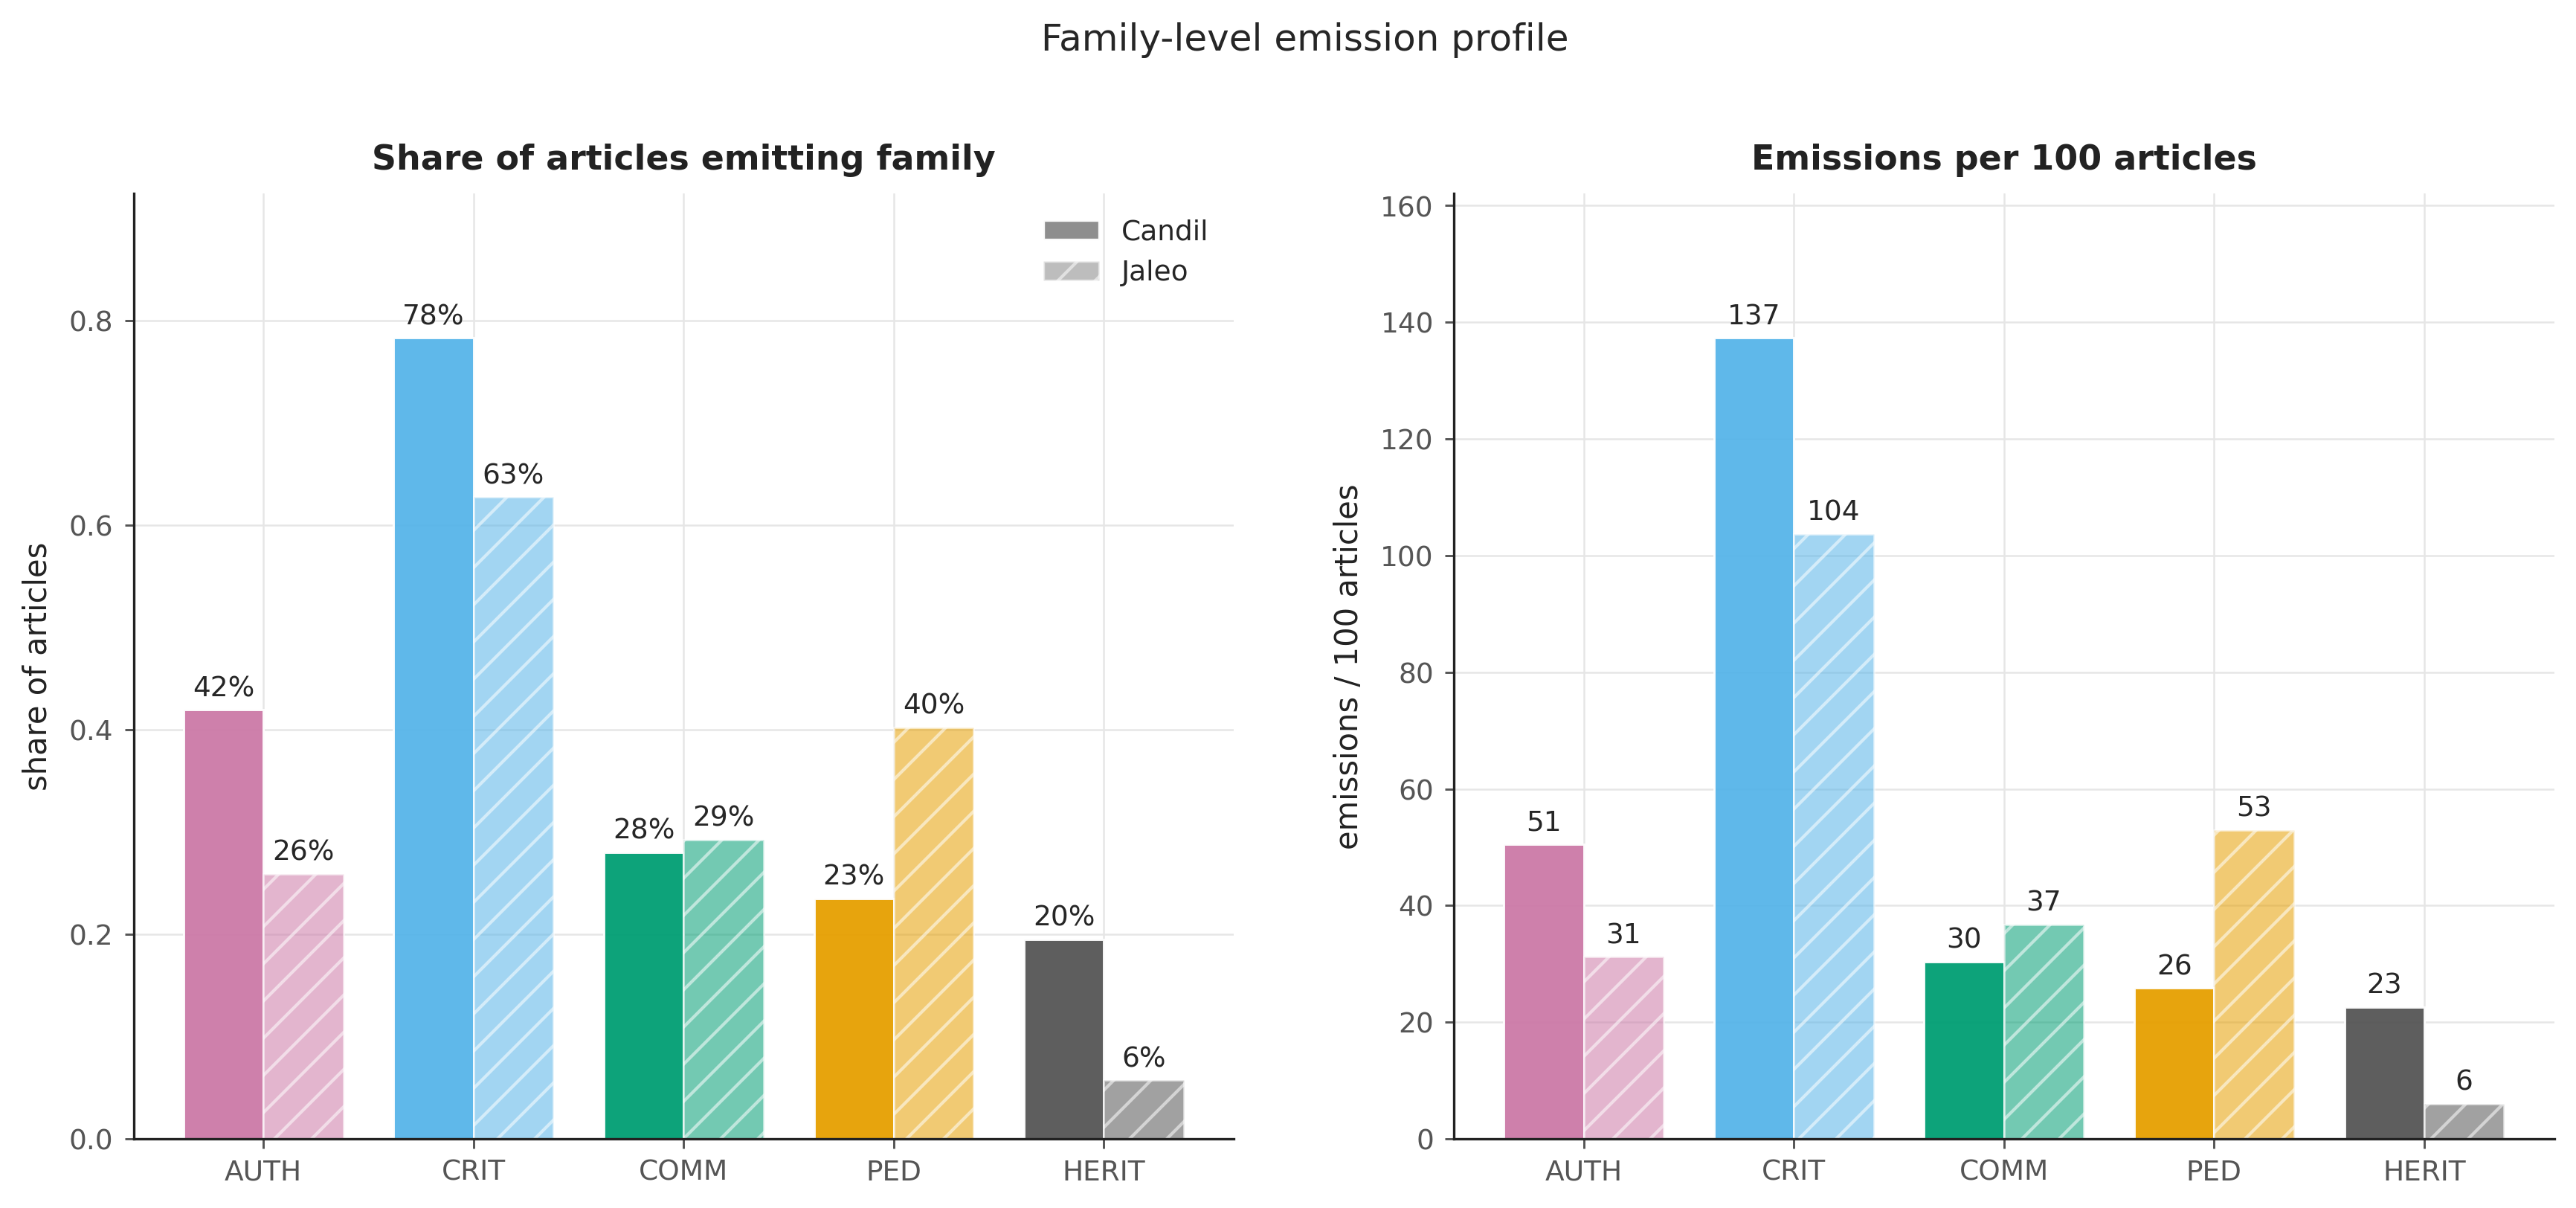

**plot_04_code_heatmap** -- full code emission heatmap

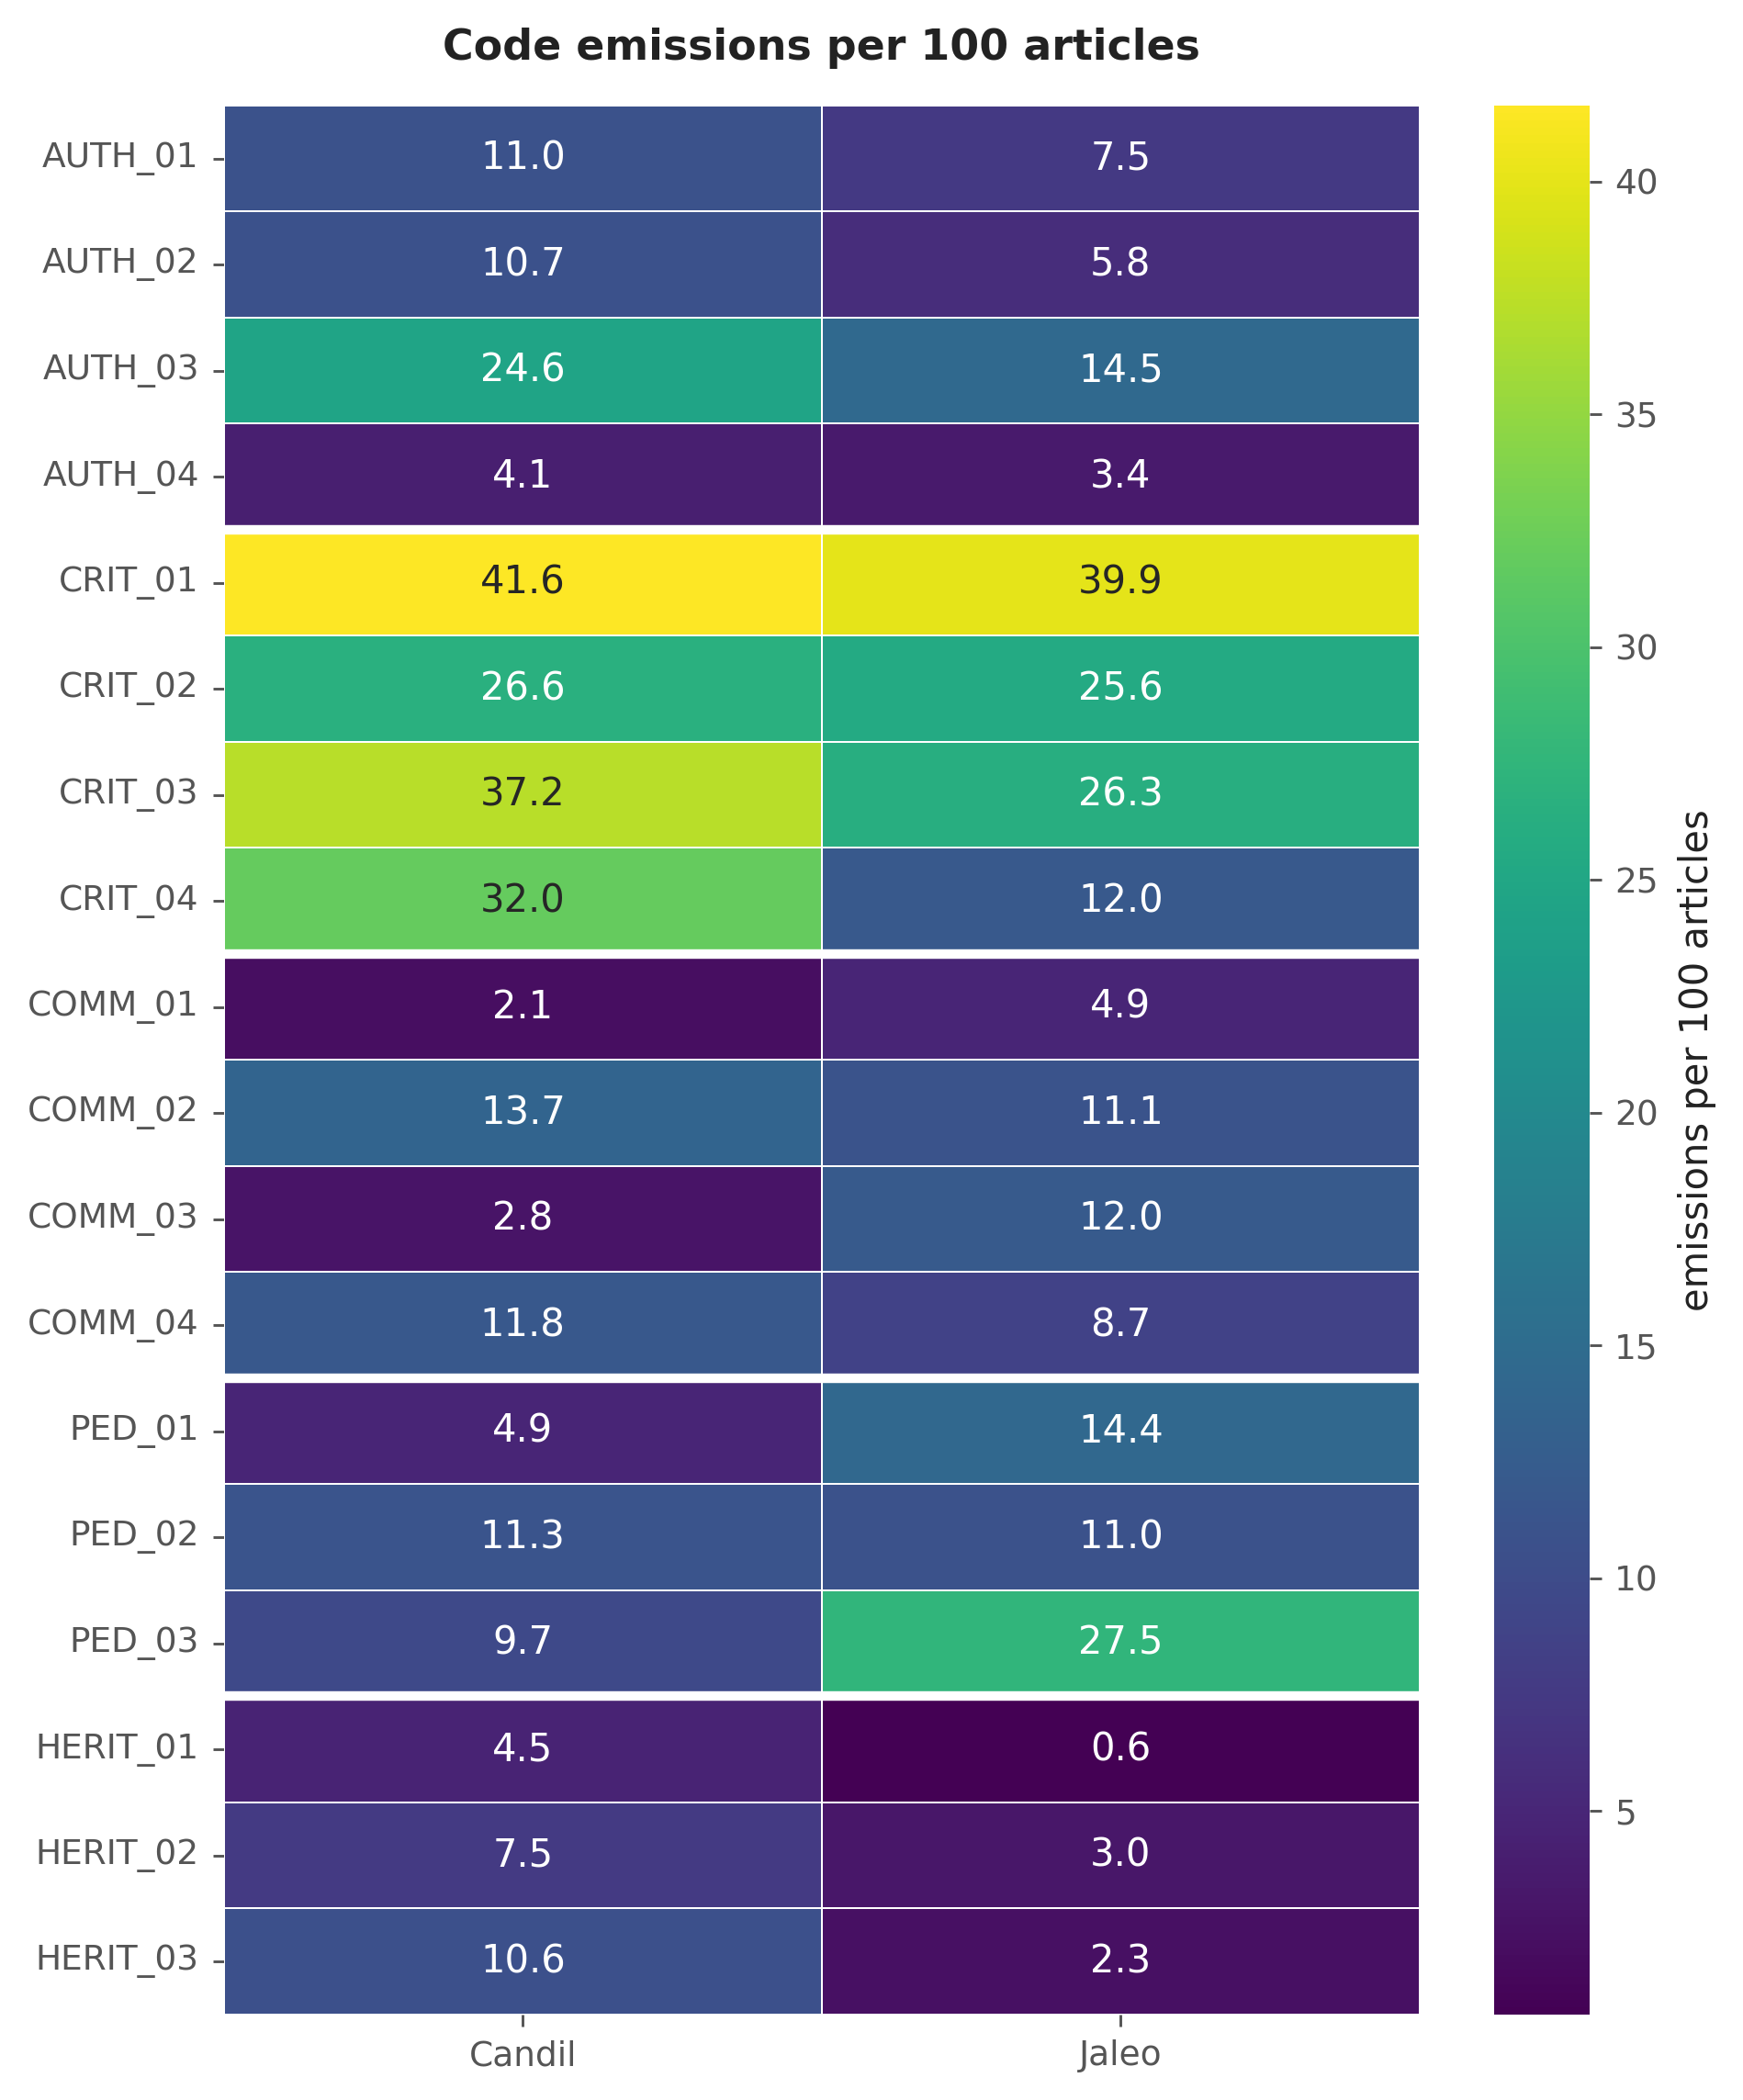

In [8]:
def show(stem, caption=None):
    if caption:
        display(Markdown(f'**{stem}** -- {caption}'))
    display(Image(filename=str(FIGS_DIR / f'{stem}.png')))

show('plot_01_coverage', 'annotation coverage decisions per periodical')
show('plot_02_codes_per_article', 'codes-per-article distribution')
show('plot_03_family_emission', 'family-level emission profile')
show('plot_04_code_heatmap', 'full code emission heatmap')

## 2. Confidence & derived analysis

**plot_05_confidence_by_family** -- confidence shares per family

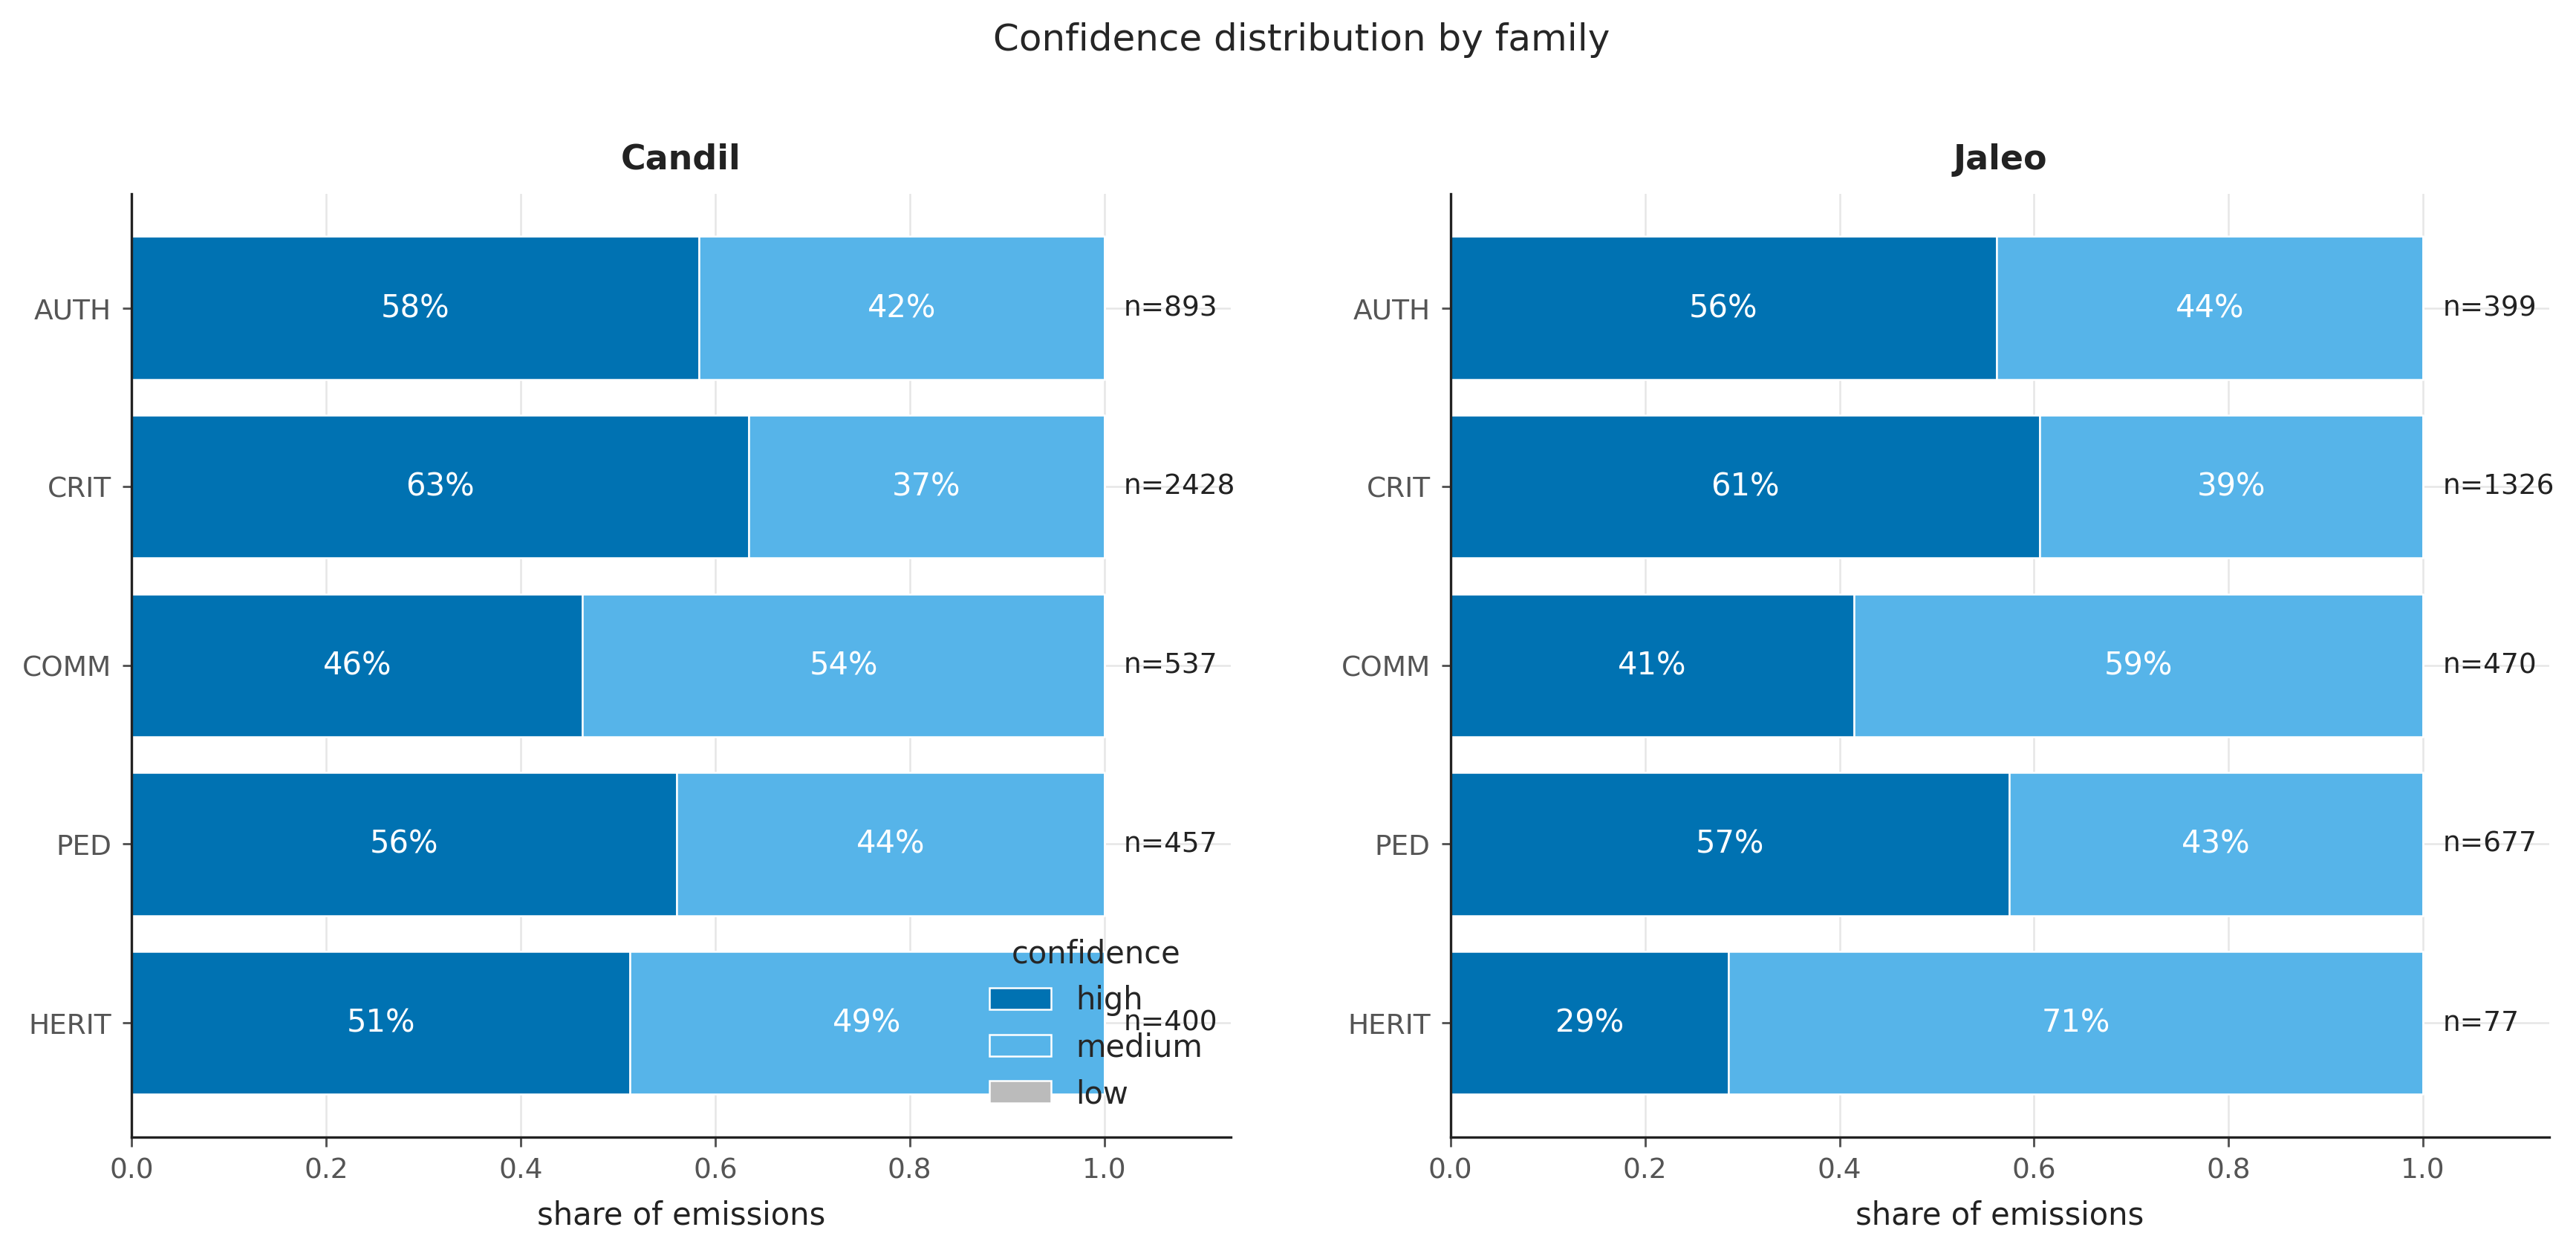

**plot_06_polarity_distribution** -- polarity counts and shares

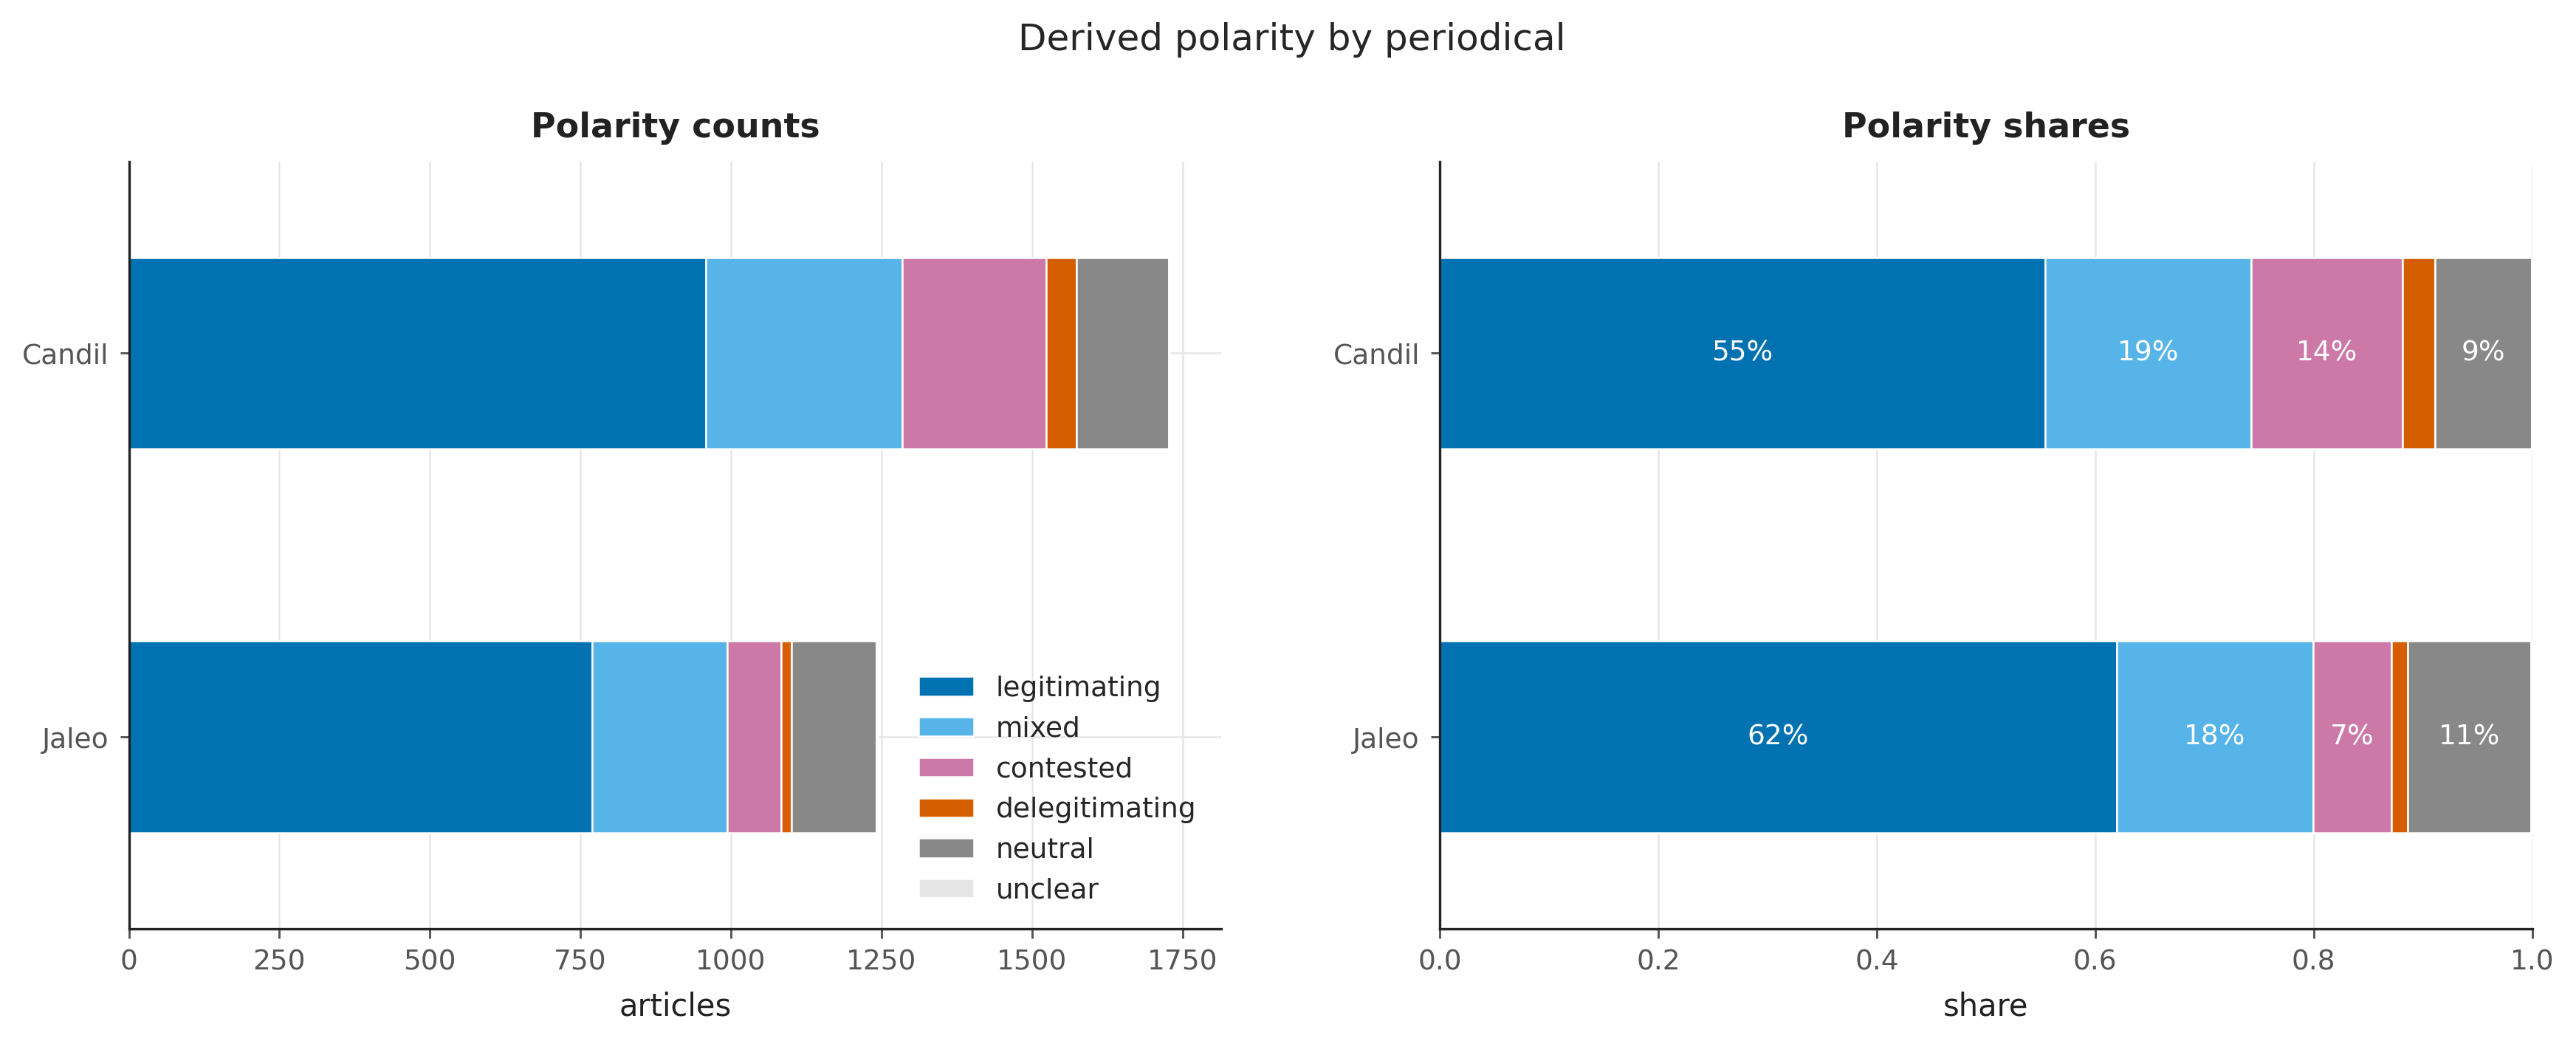

**plot_07_basis_distribution** -- legitimation basis tags

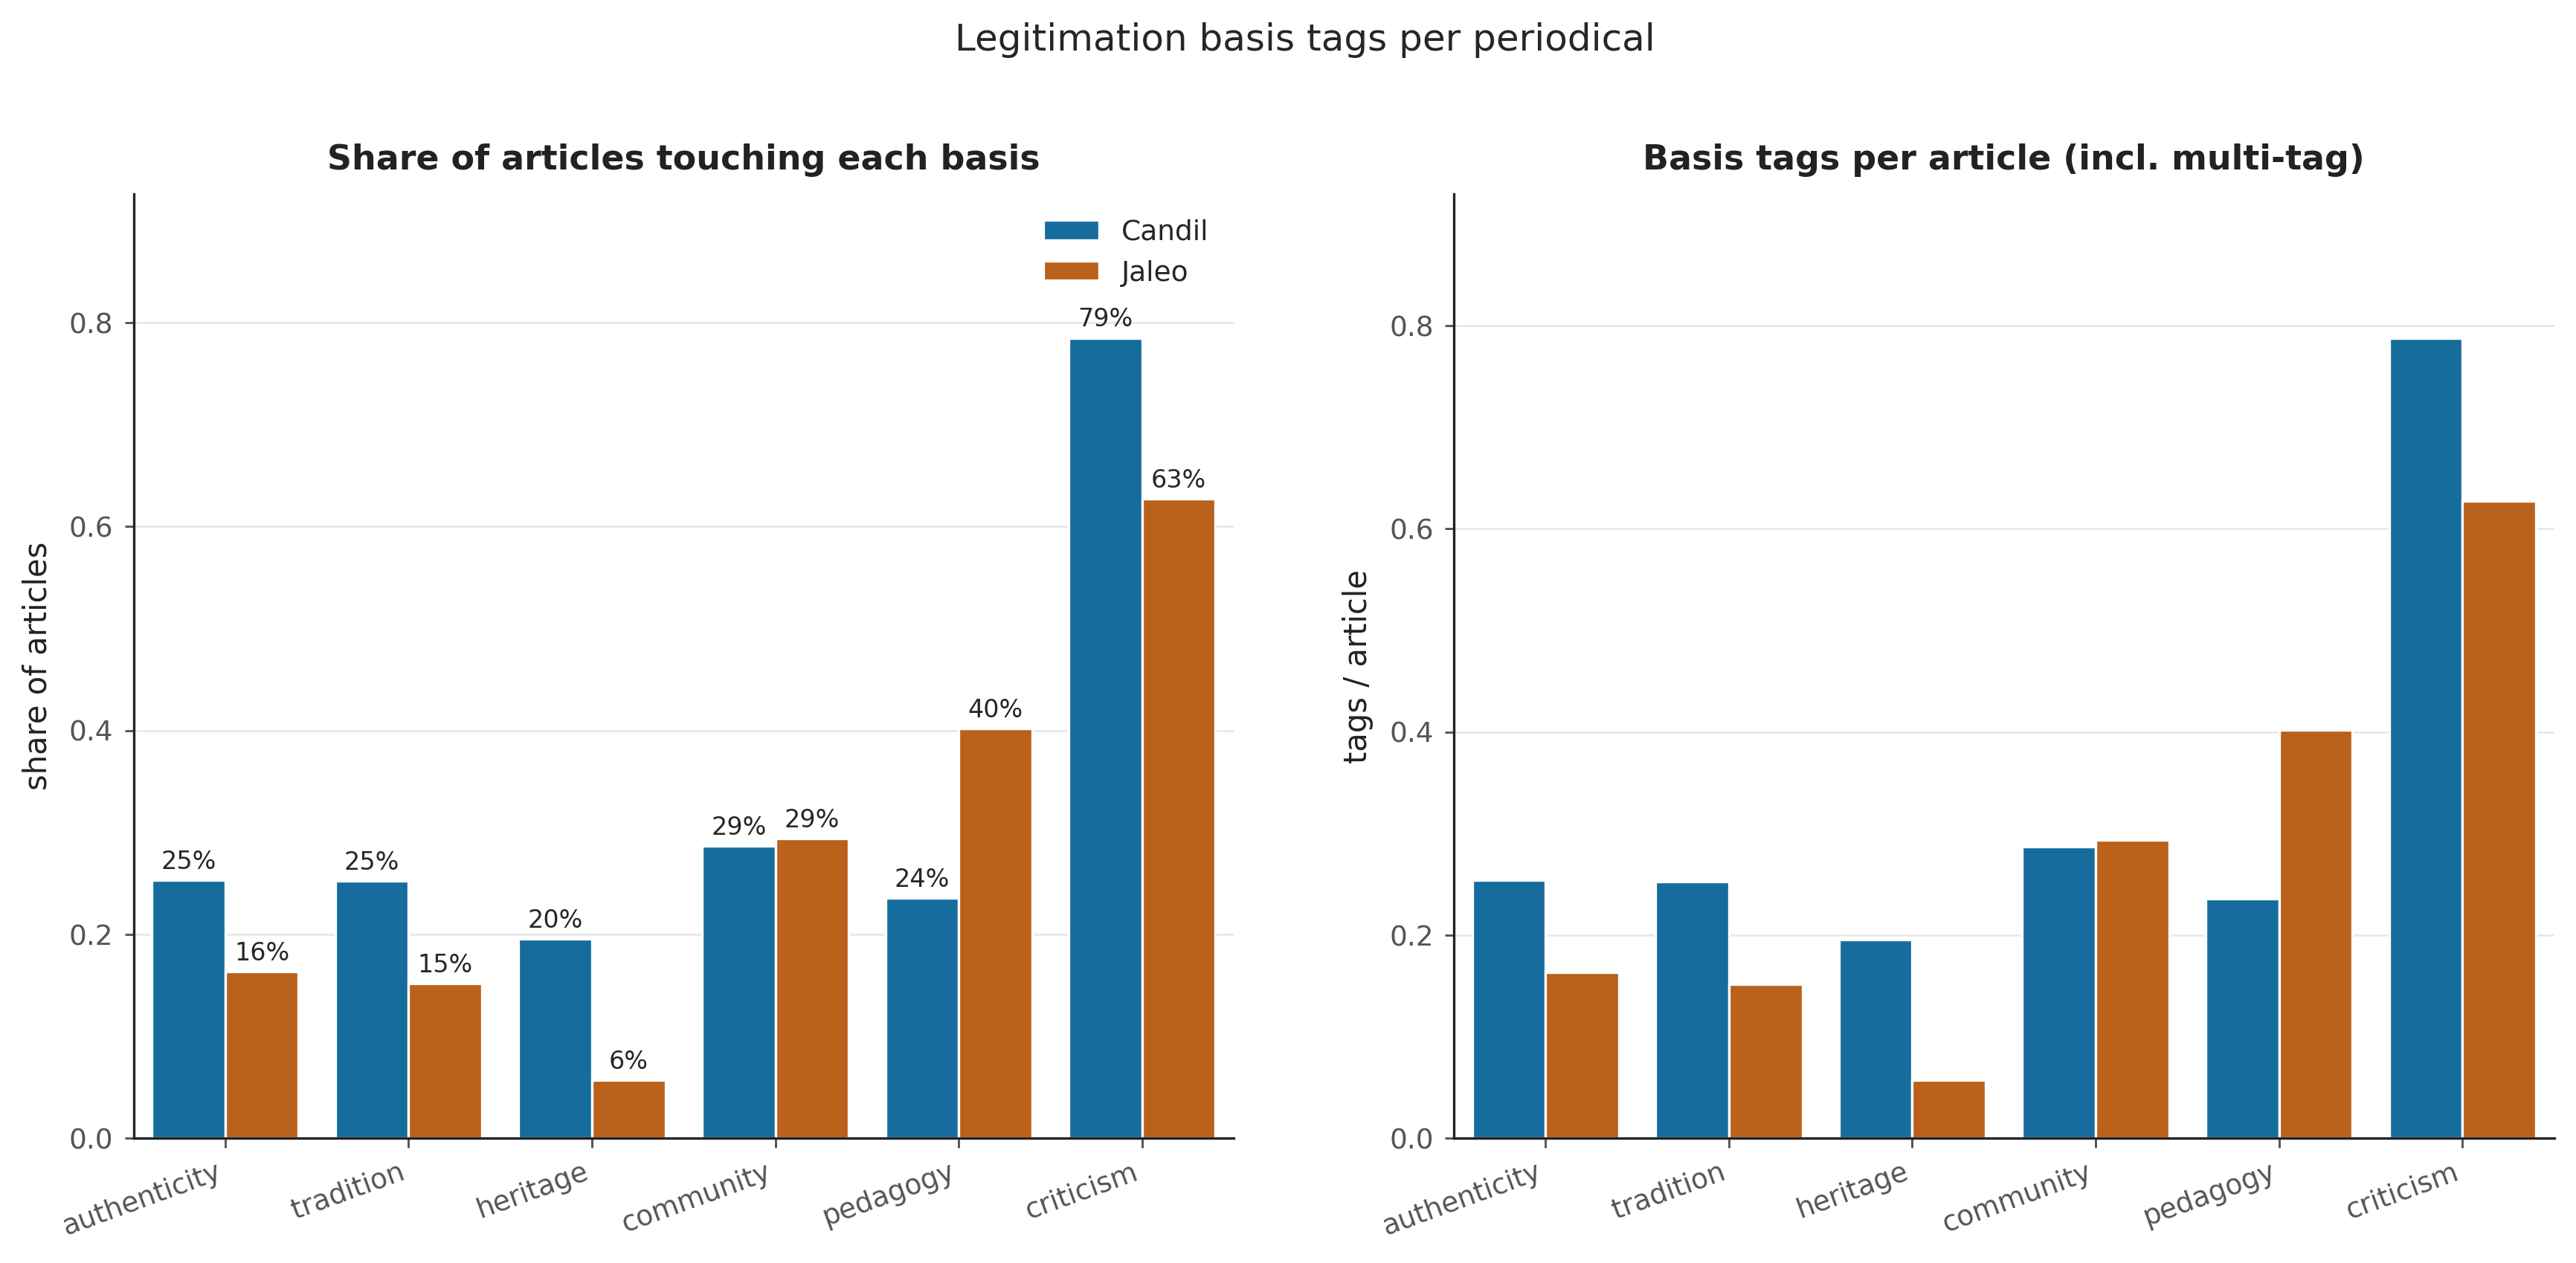

**plot_08_legitimation_and_boundaries** -- derived flag rates

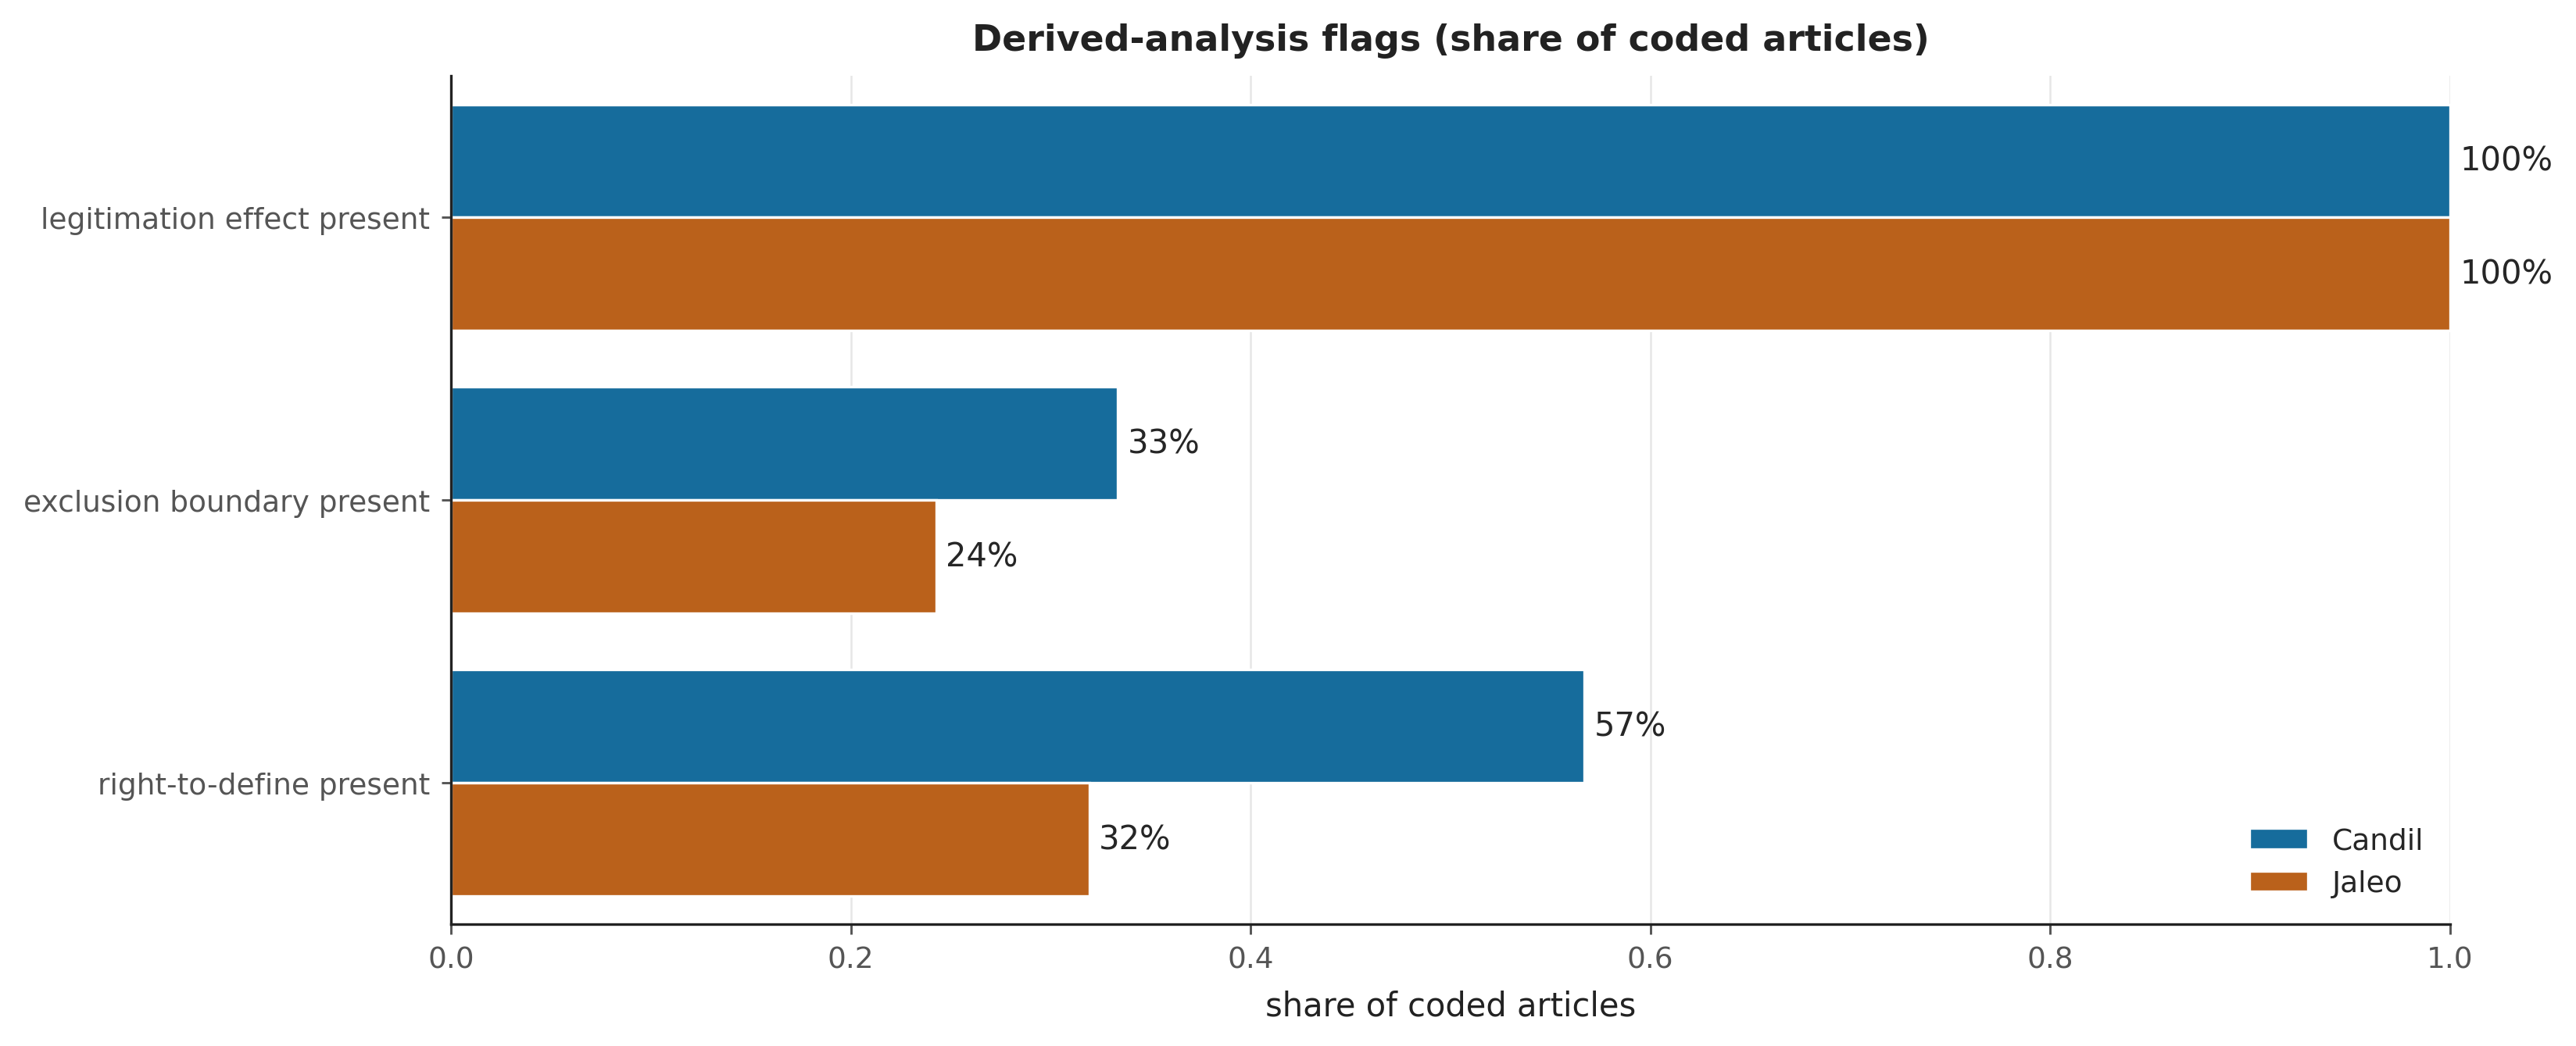

**plot_09_polarity_basis_heatmap** -- polarity x basis co-occurrence

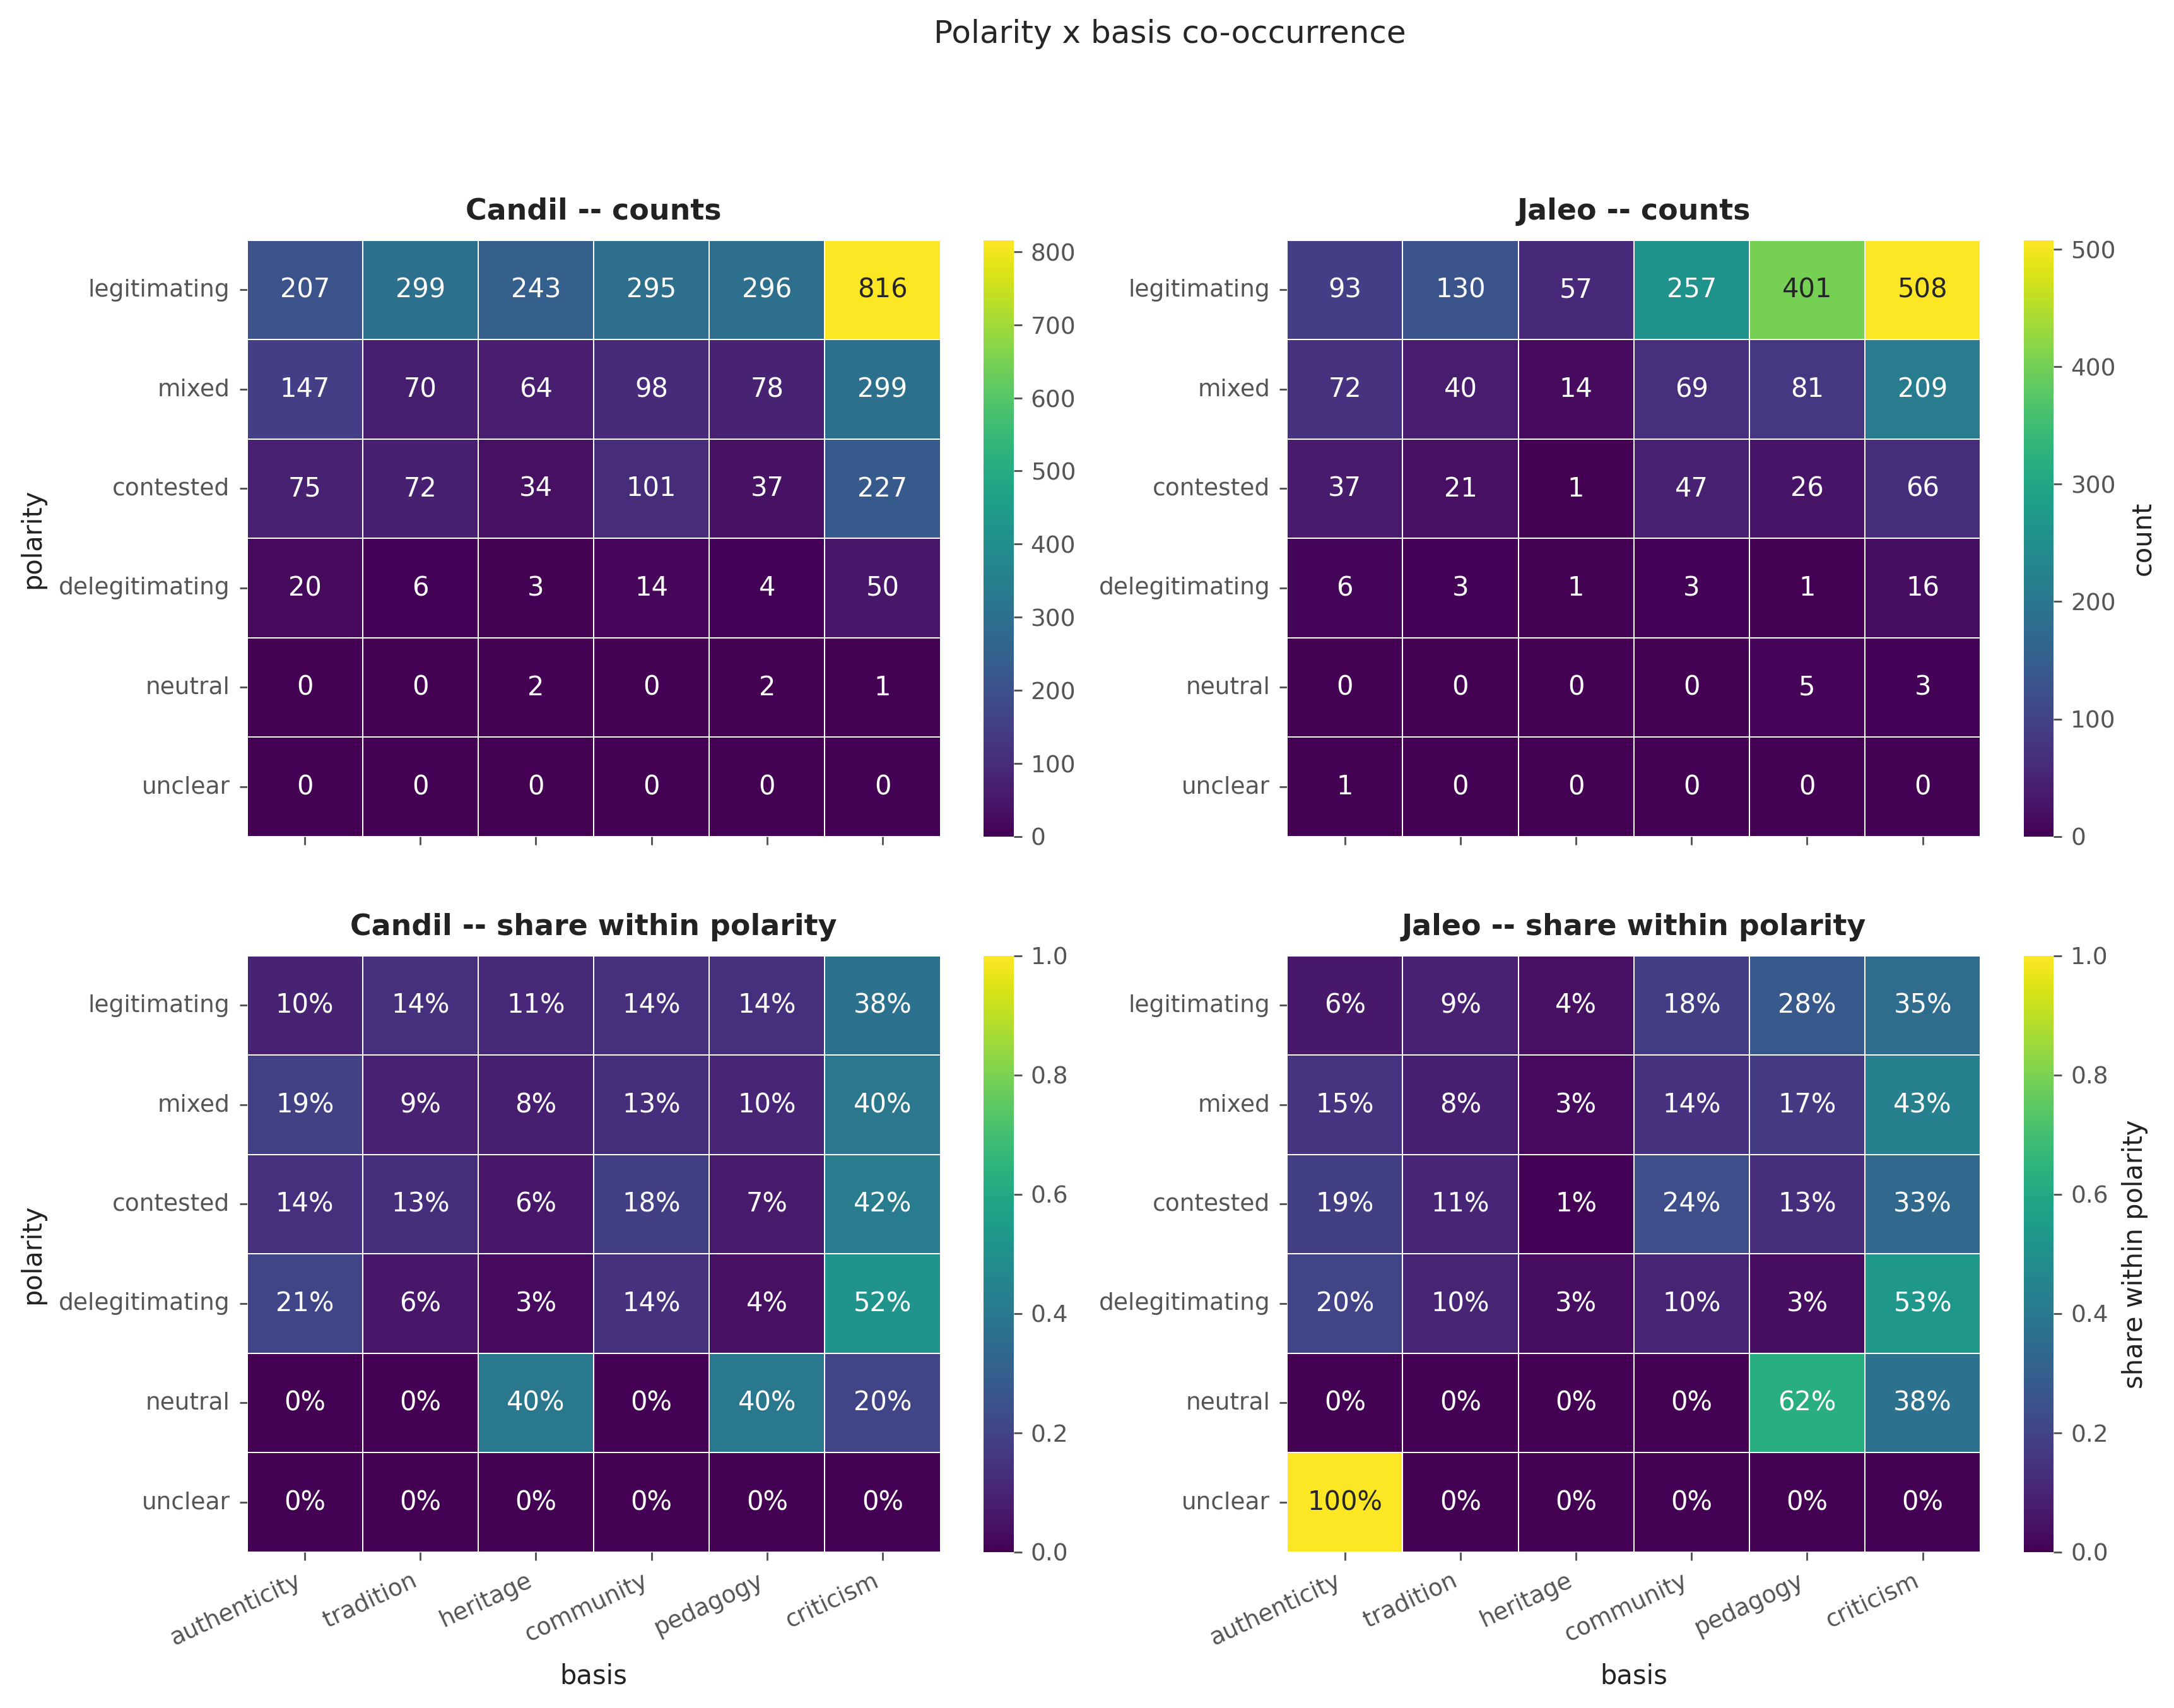

In [9]:
show('plot_05_confidence_by_family', 'confidence shares per family')
show('plot_06_polarity_distribution', 'polarity counts and shares')
show('plot_07_basis_distribution', 'legitimation basis tags')
show('plot_08_legitimation_and_boundaries', 'derived flag rates')
show('plot_09_polarity_basis_heatmap', 'polarity x basis co-occurrence')

## 3. Near-misses, reasoning, targets, time

**plot_10_possible_top_codes** -- top considered-but-not-emitted codes

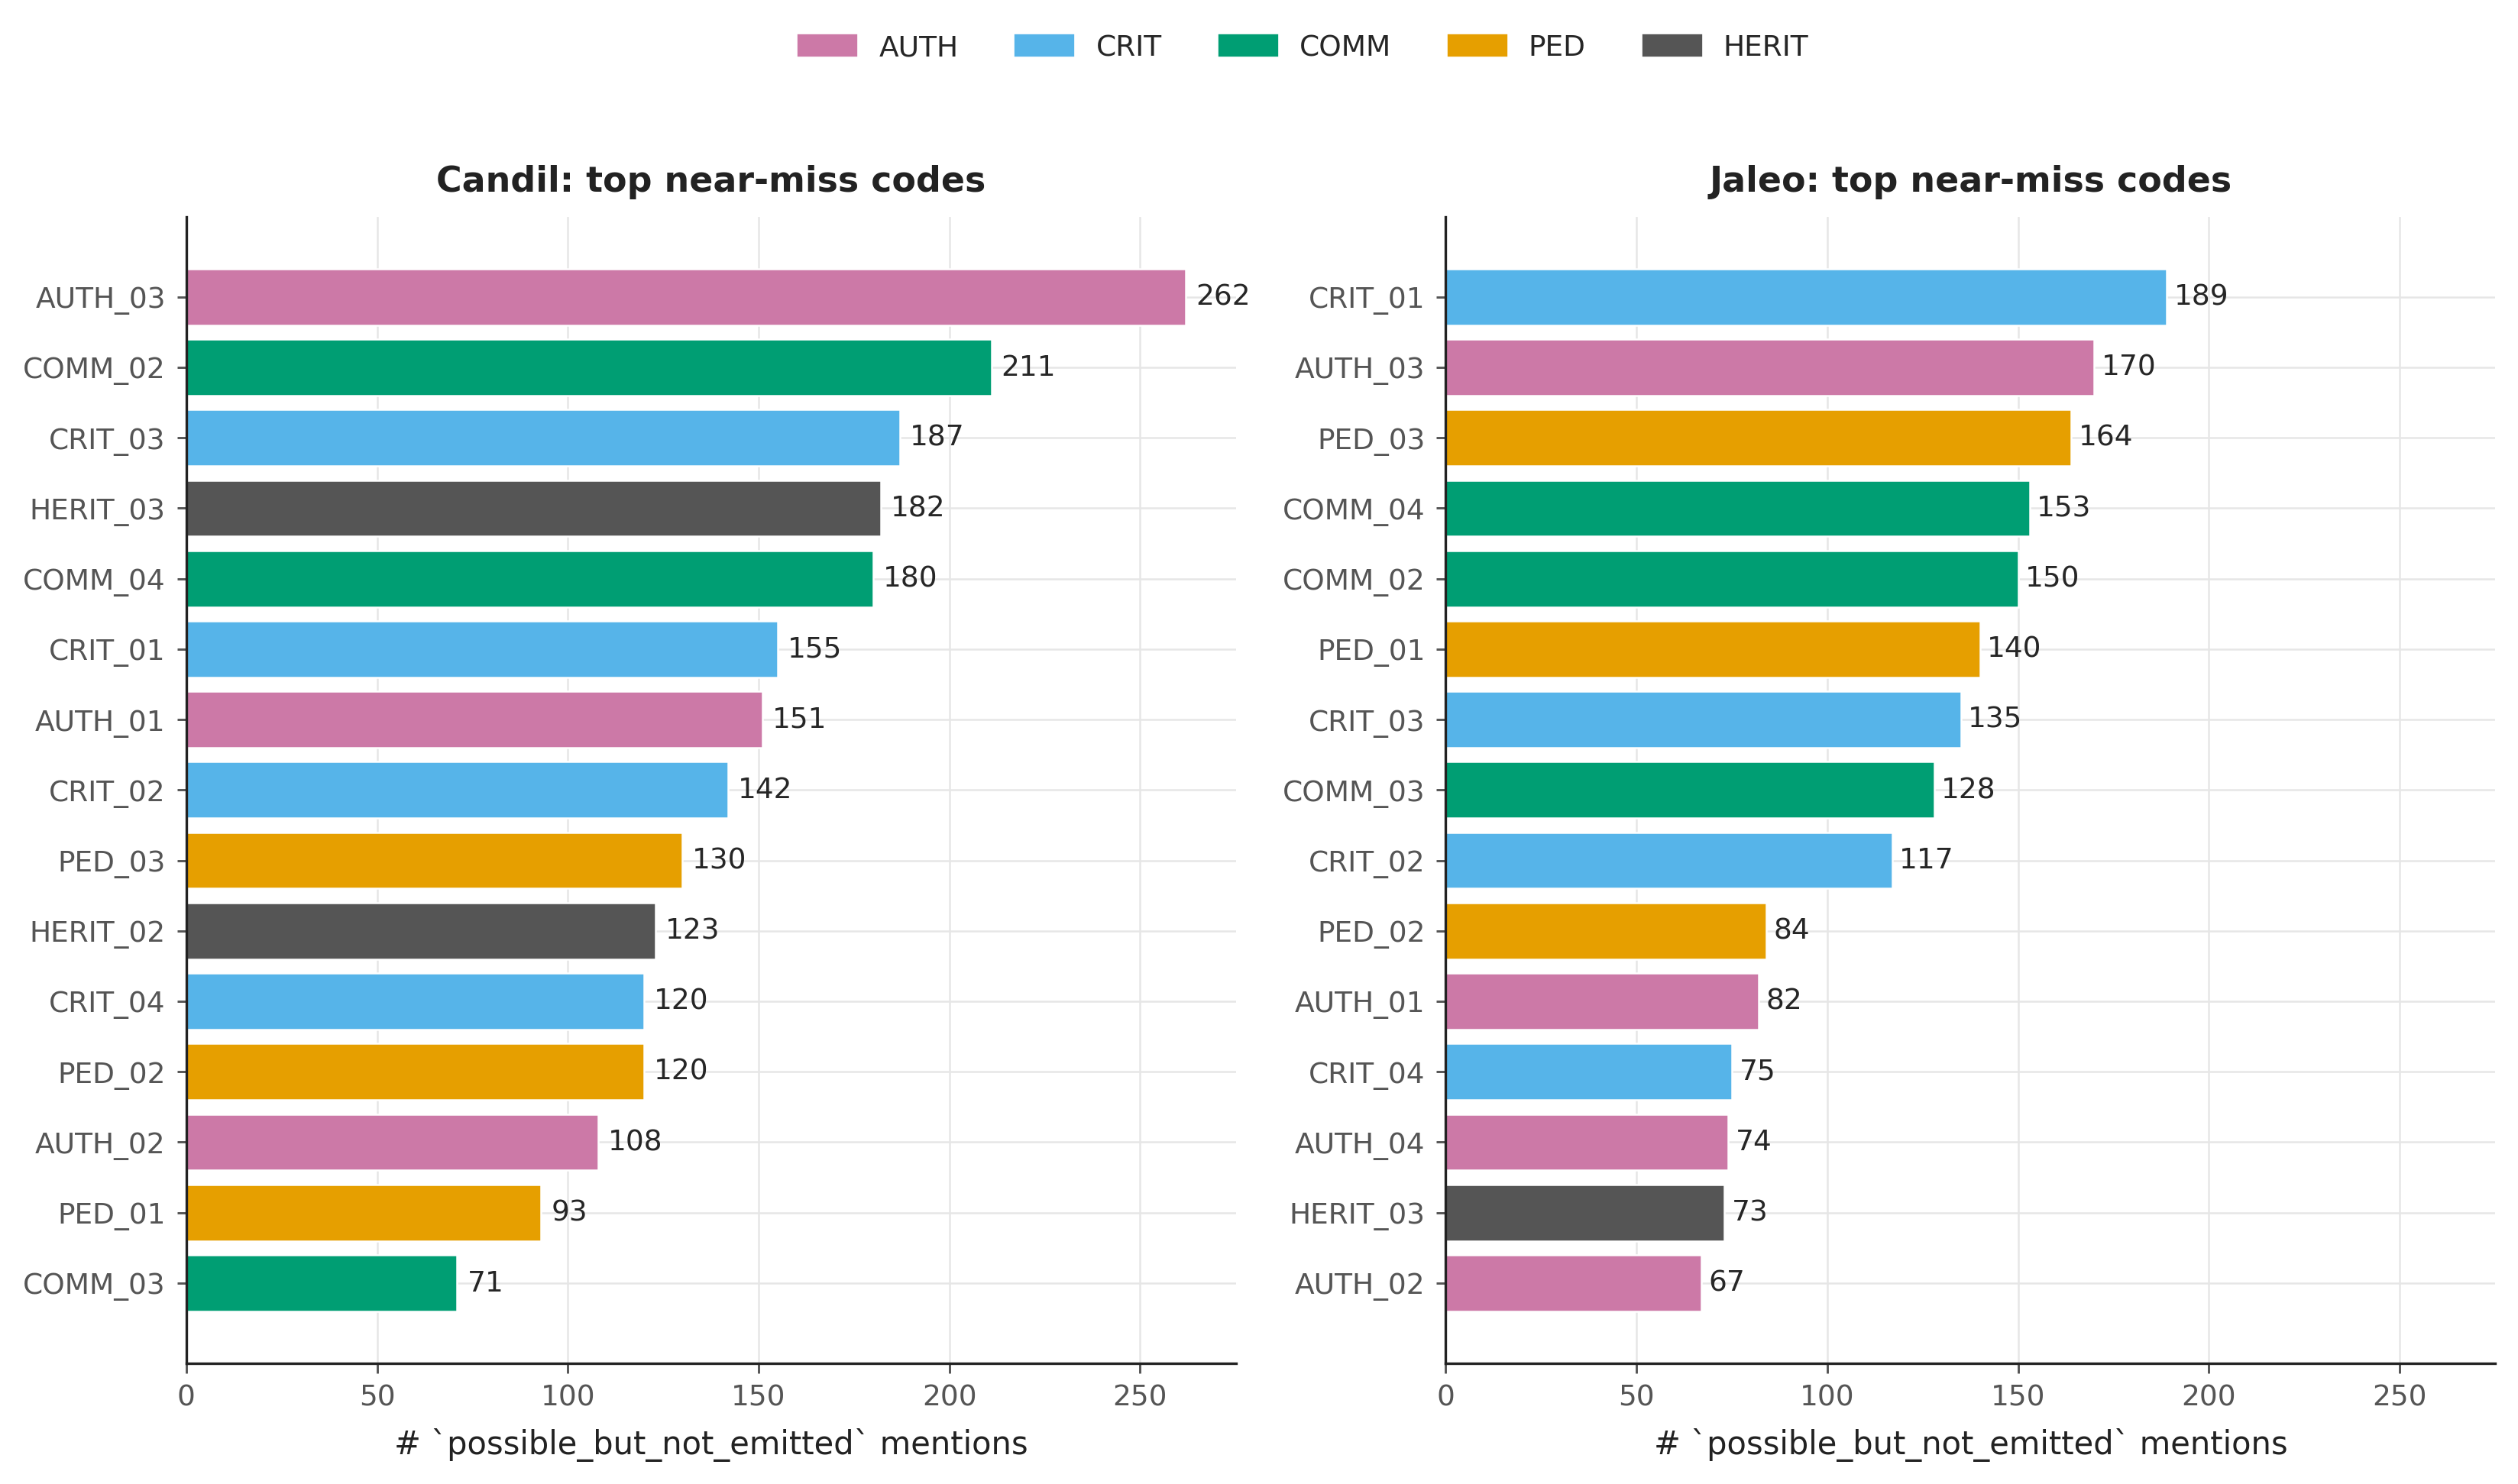

**plot_11_emit_vs_possible** -- emit vs. possible per code

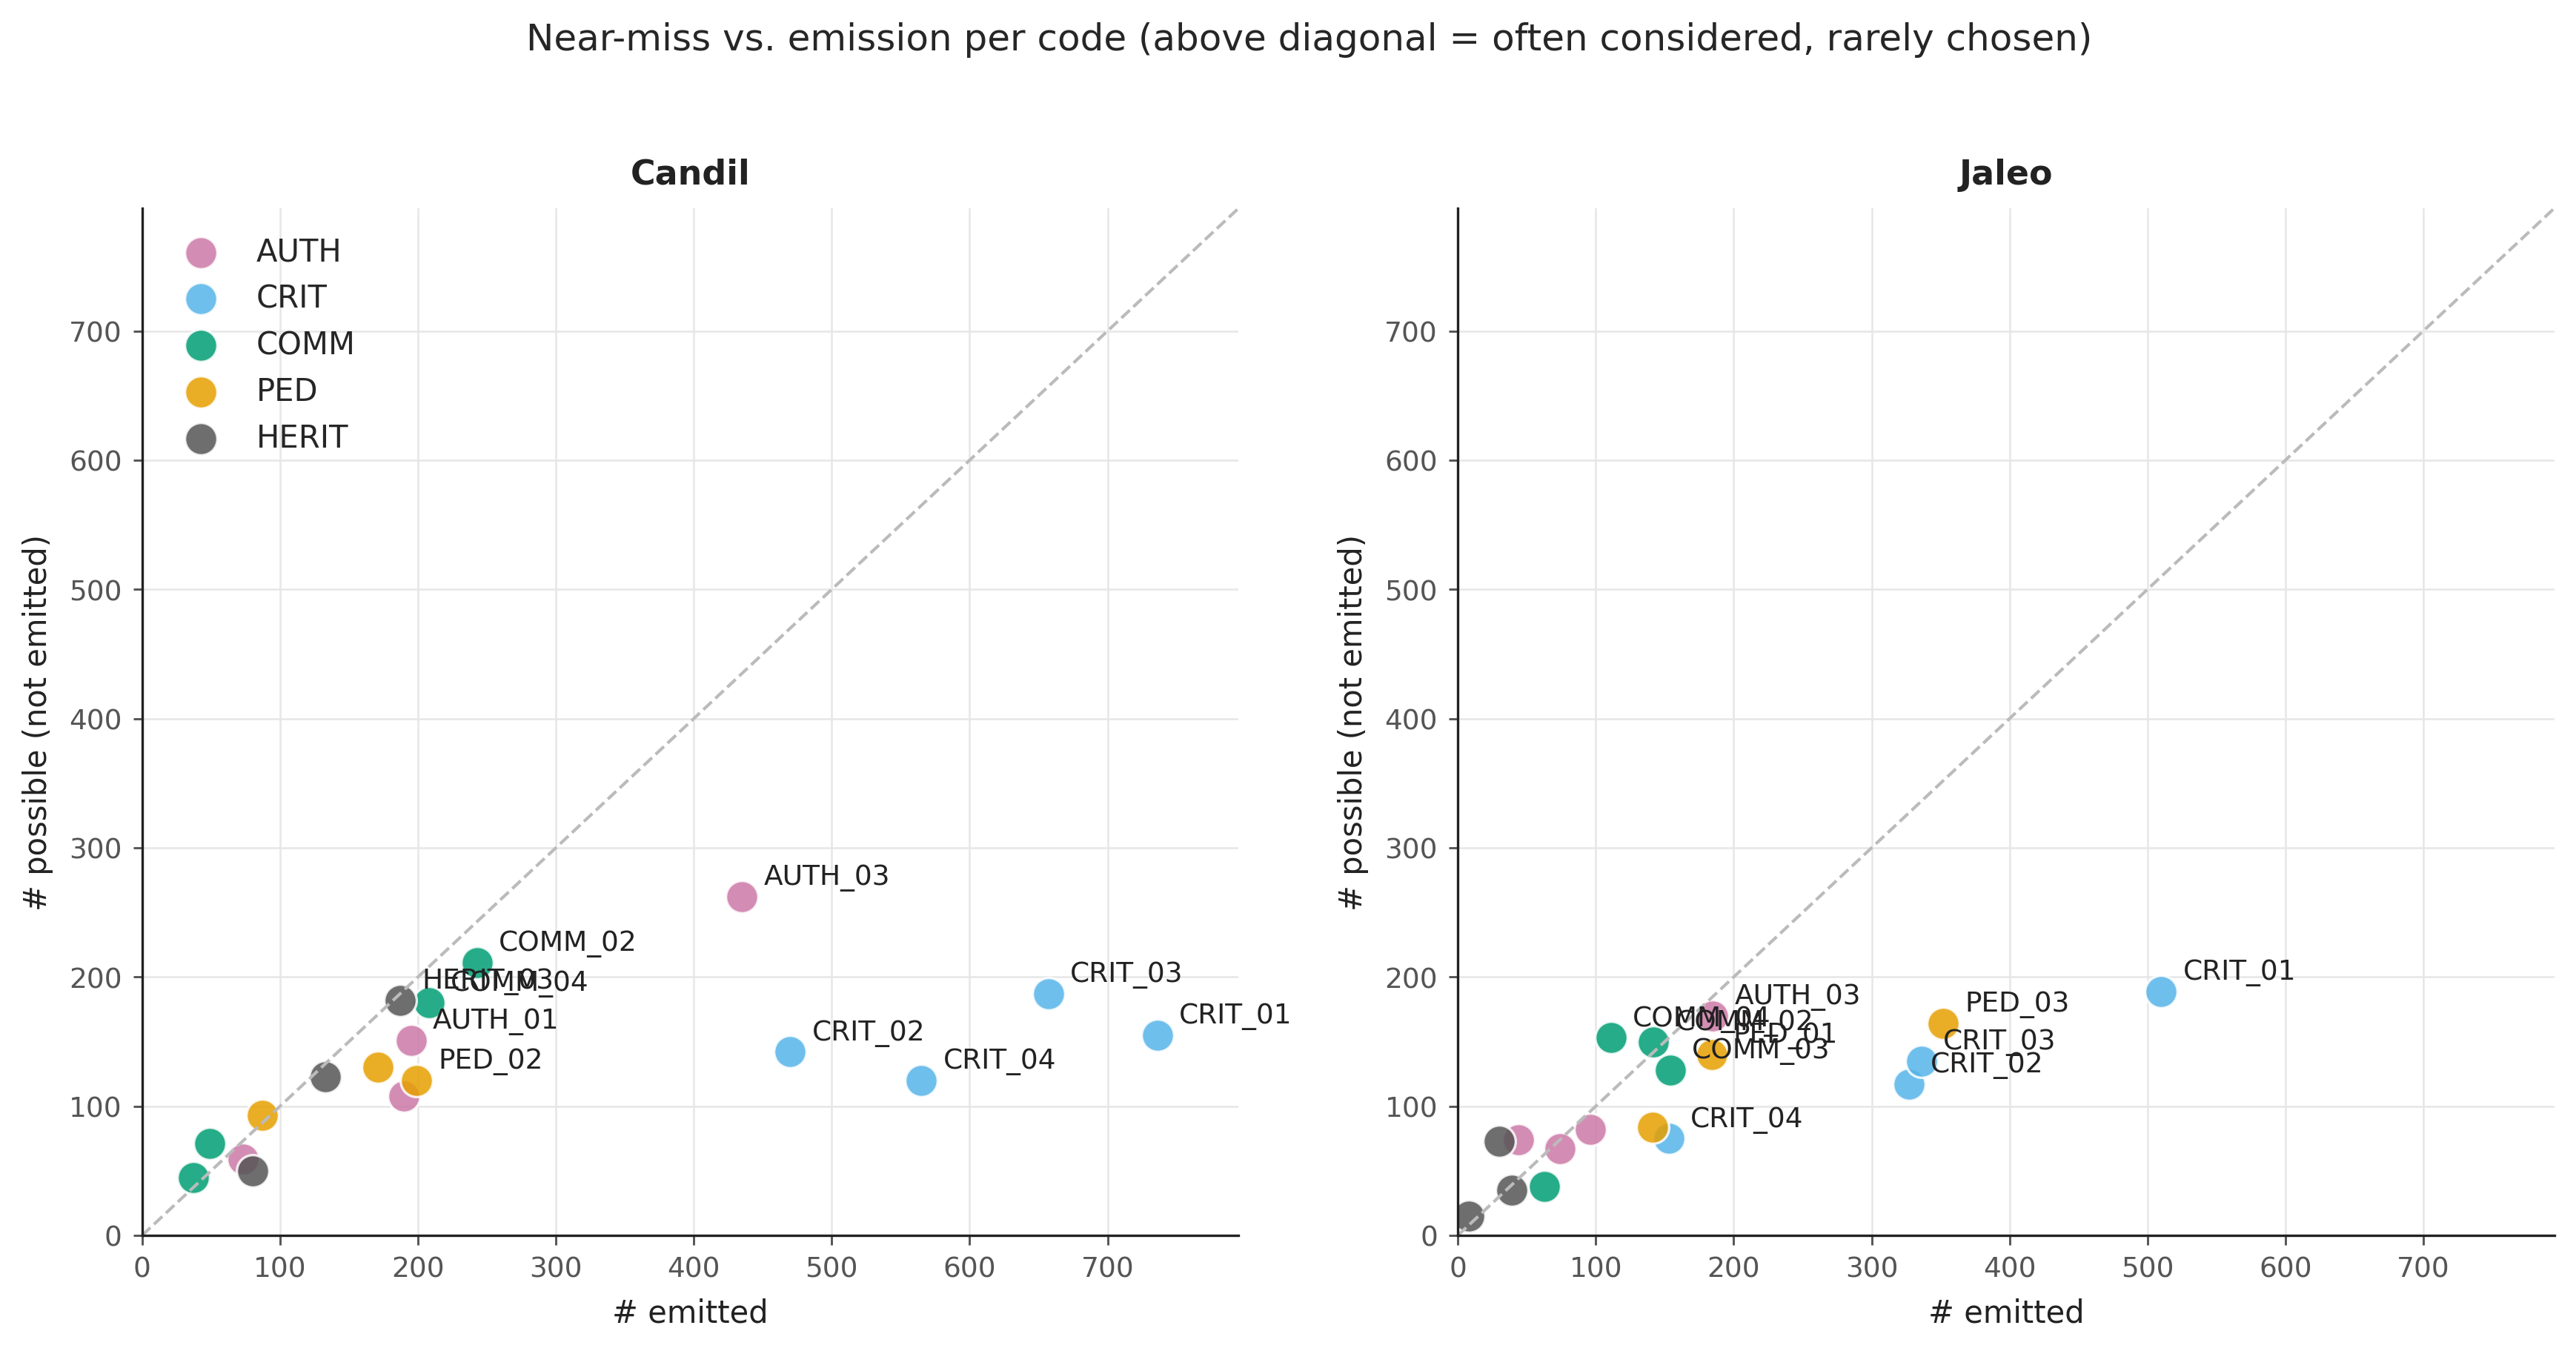

**plot_12_rationale_length** -- rationale/evidence length by confidence

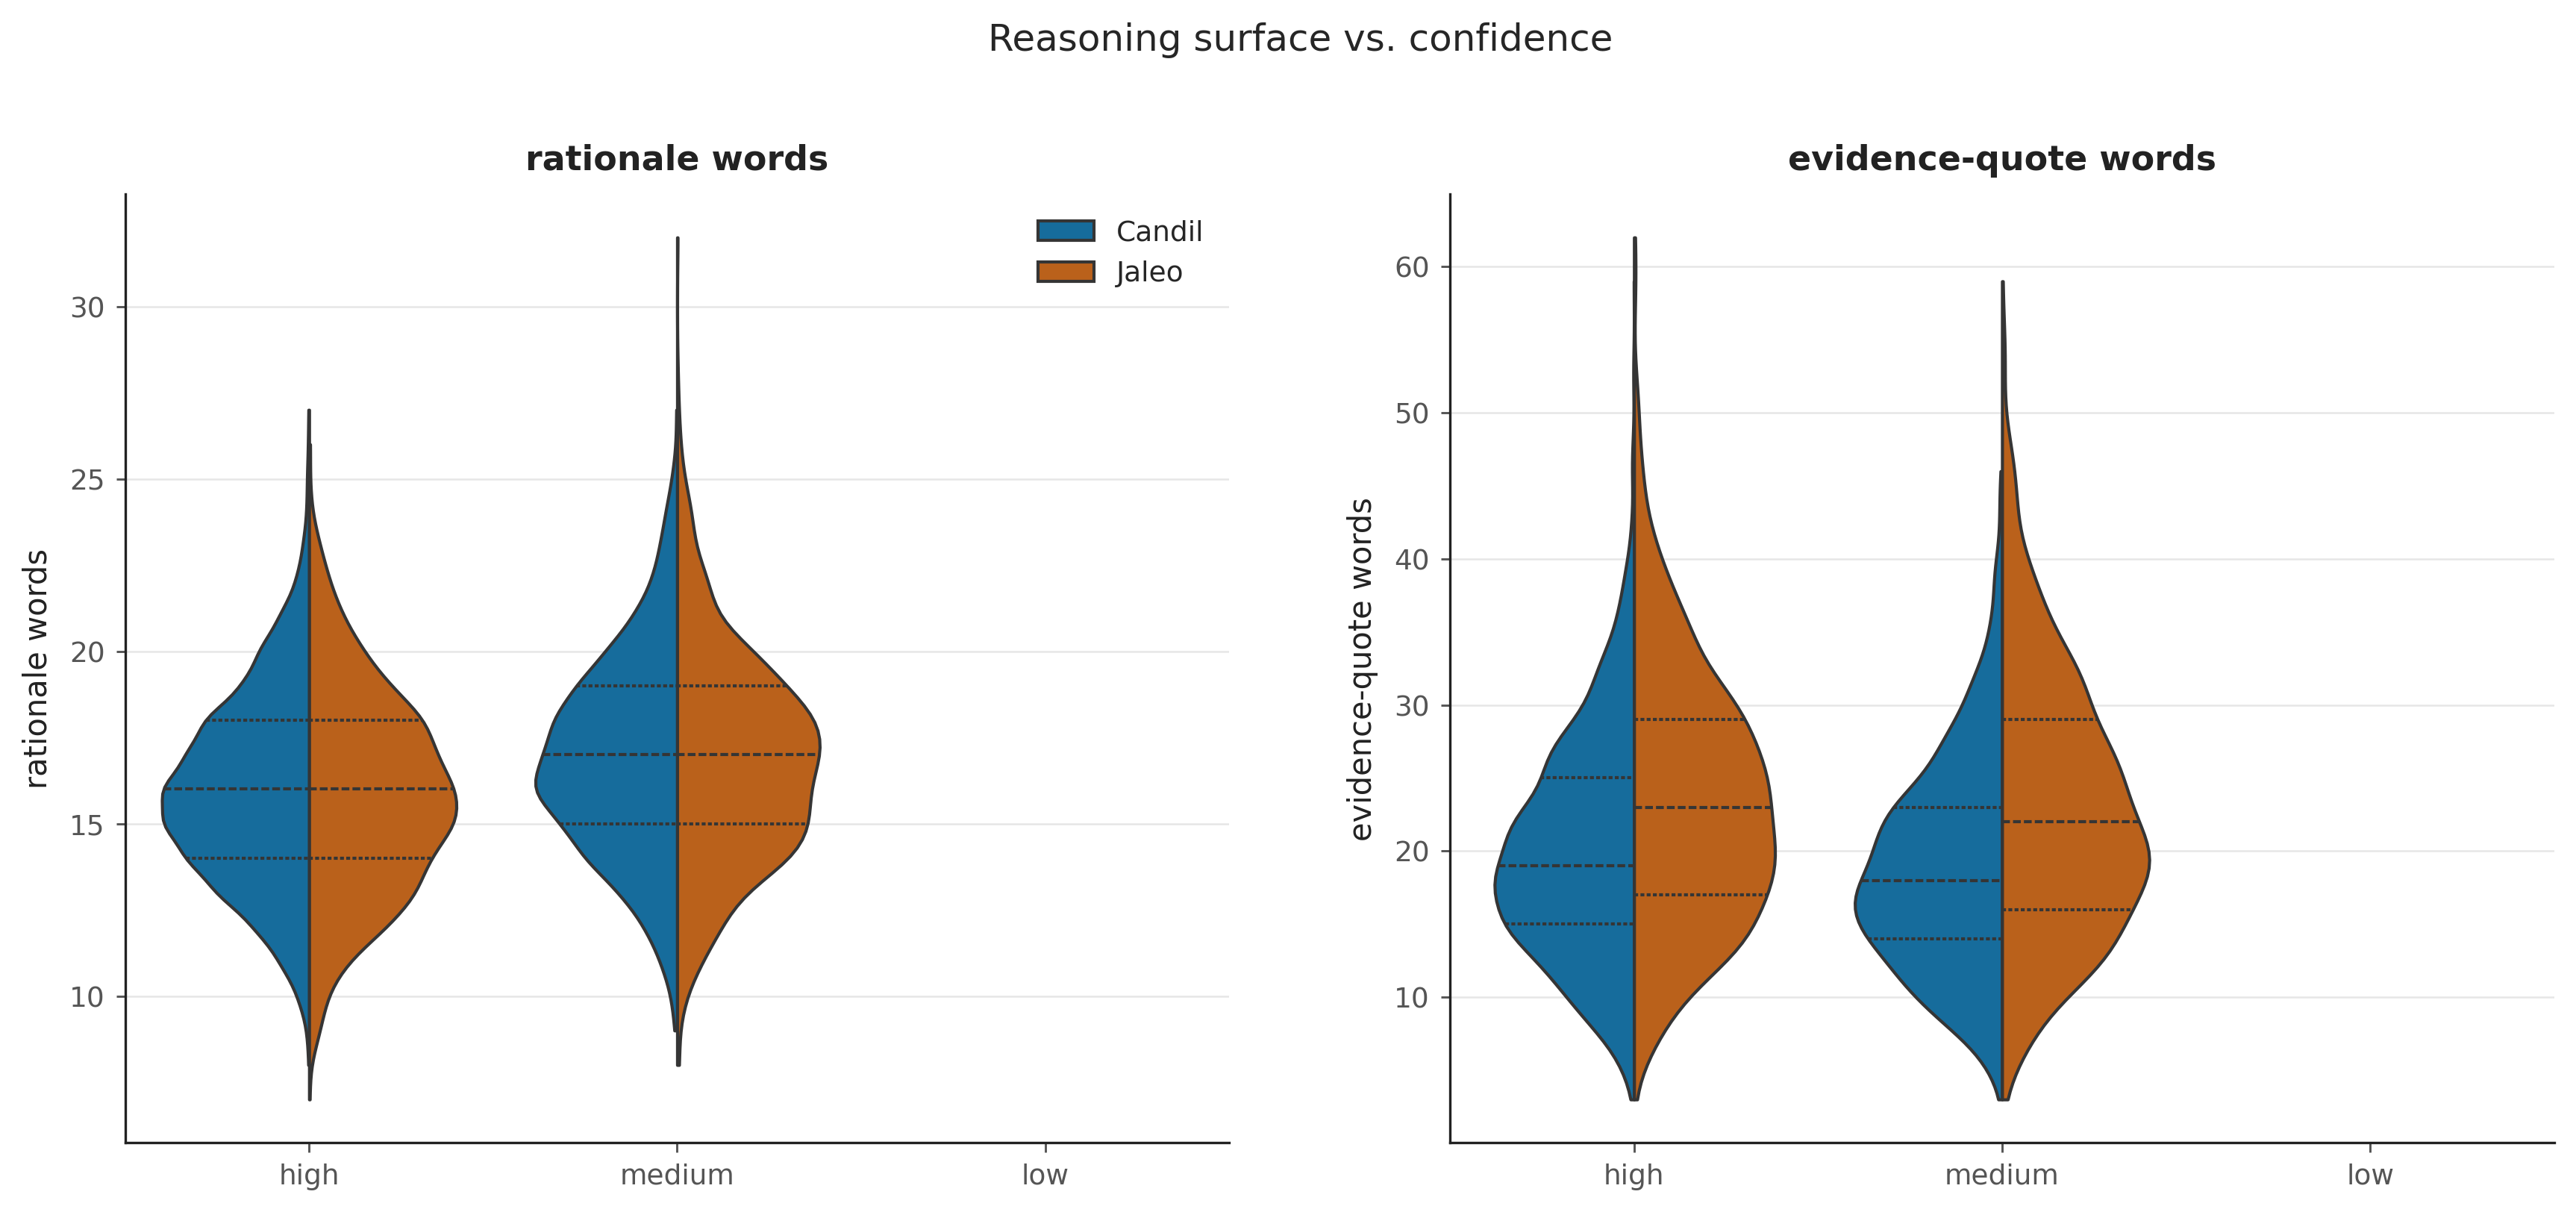

**plot_13_target_top_terms** -- top target terms per family

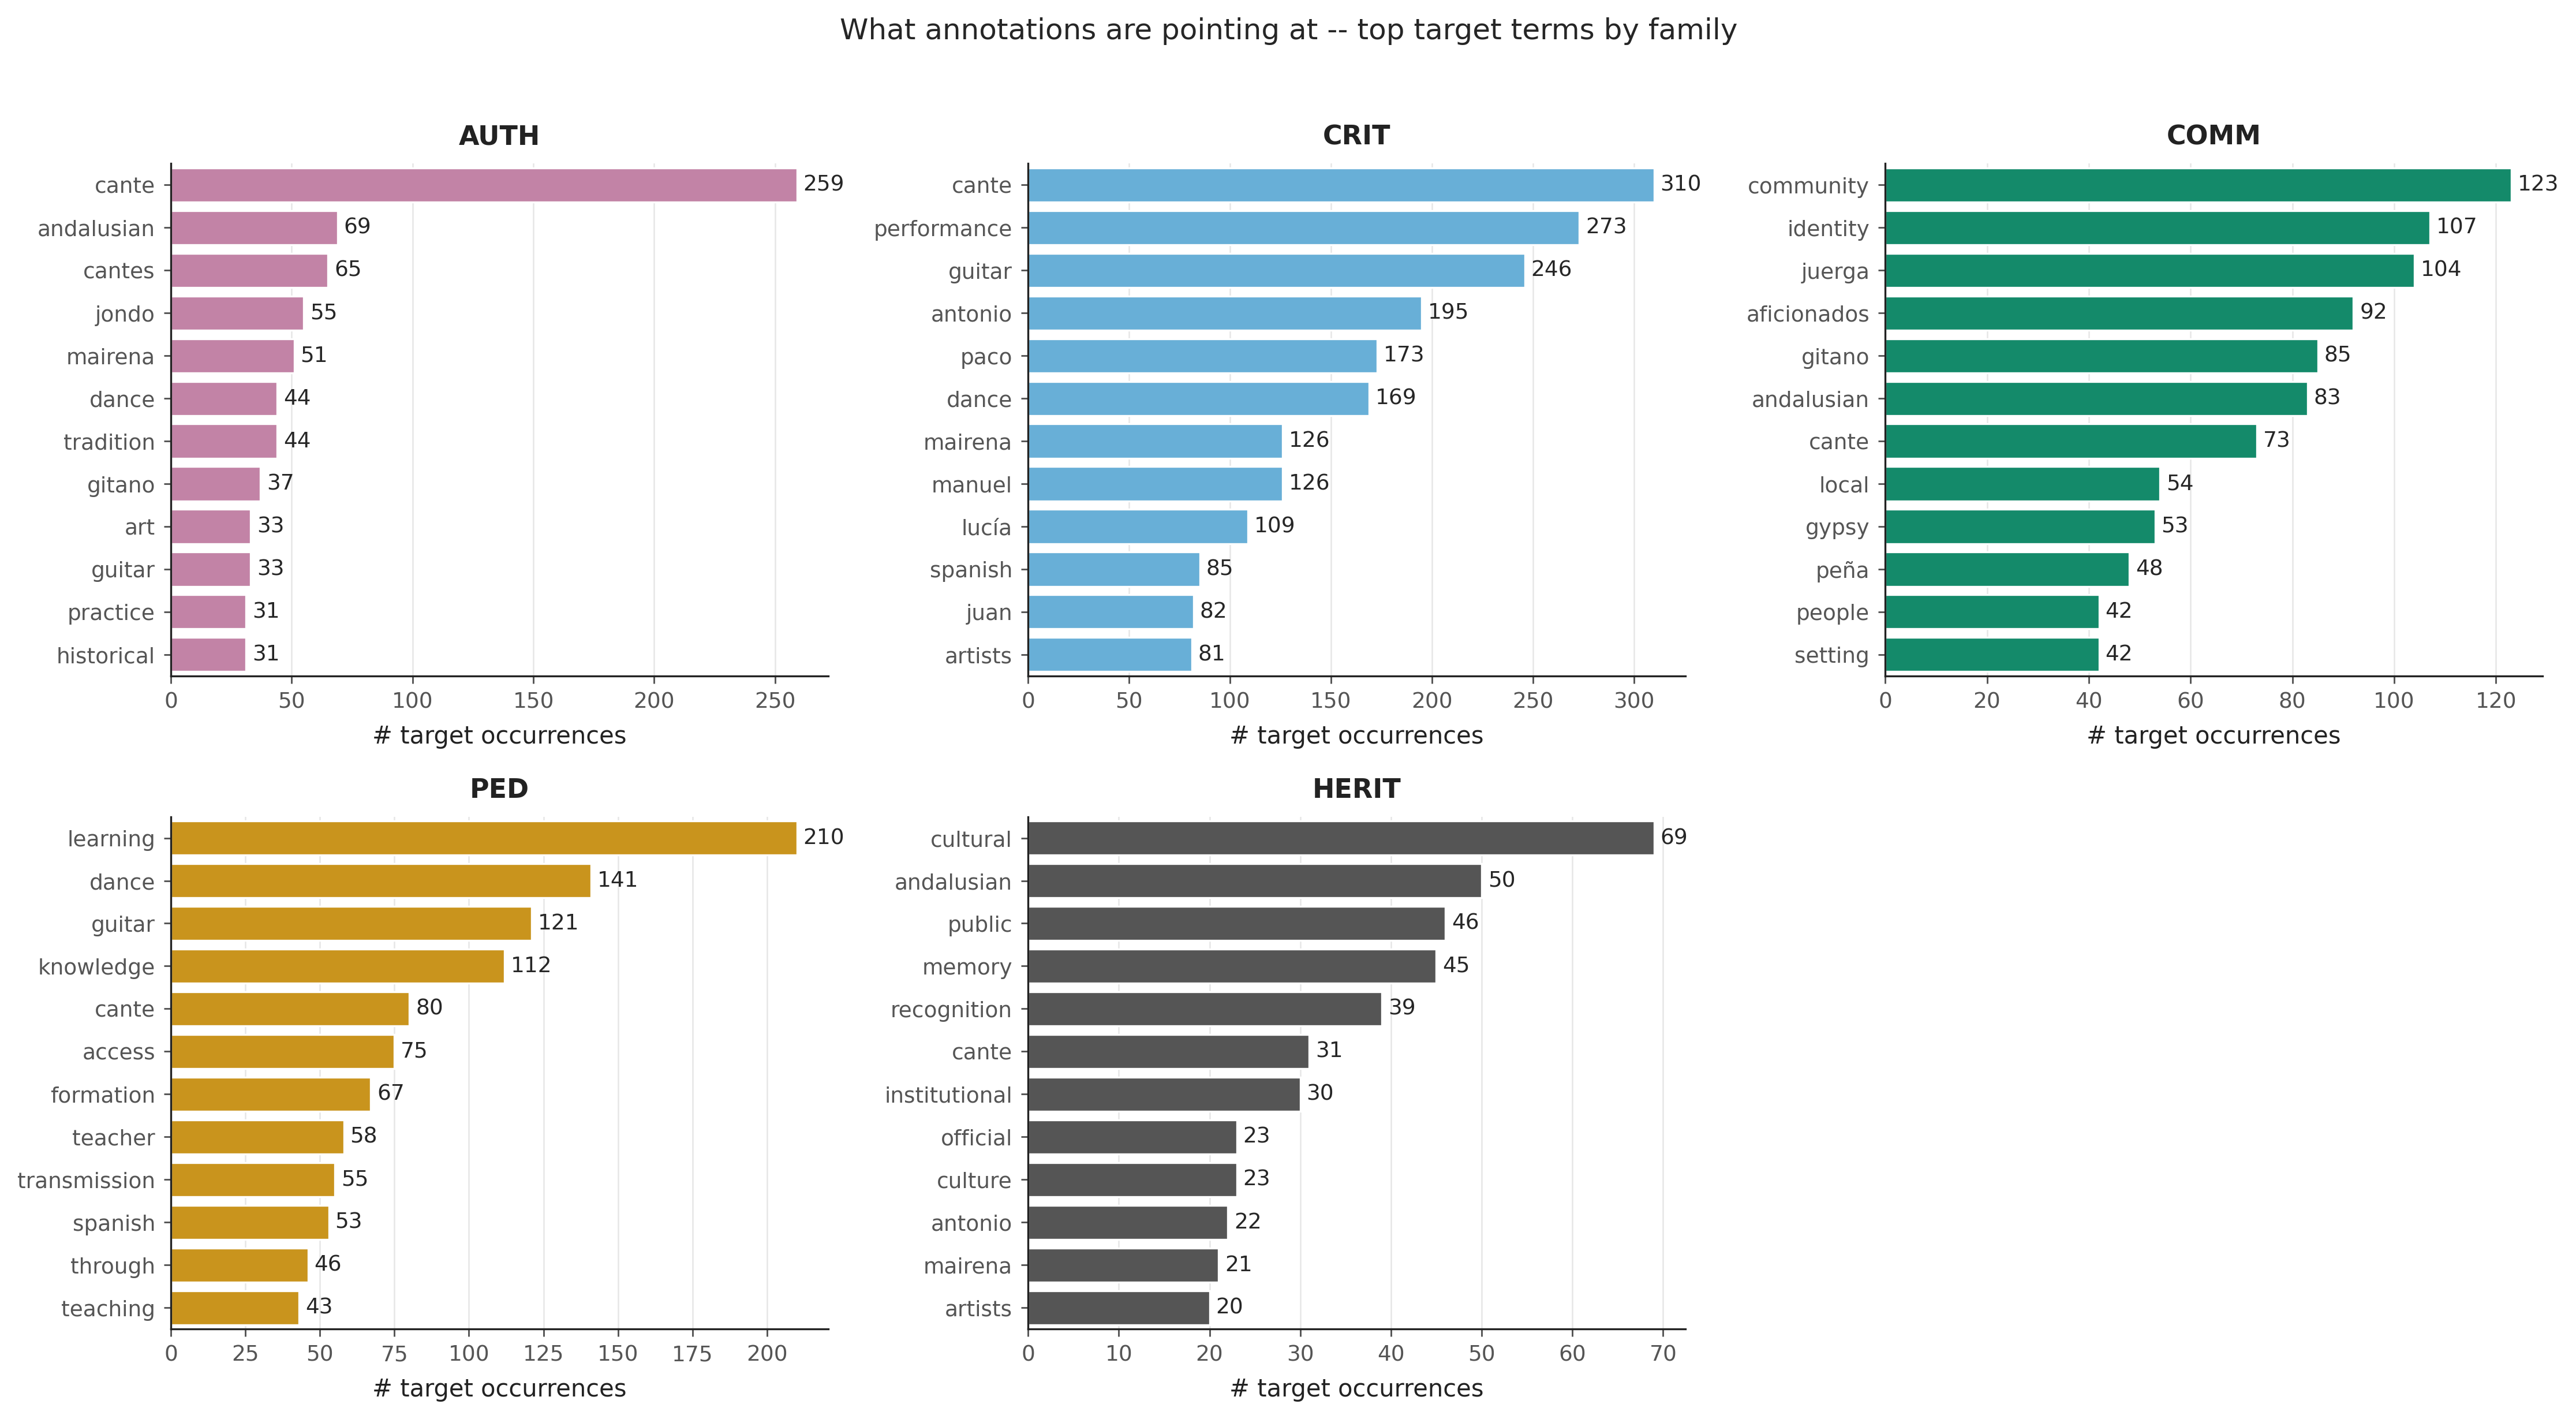

**plot_14_temporal_family** -- family share over time

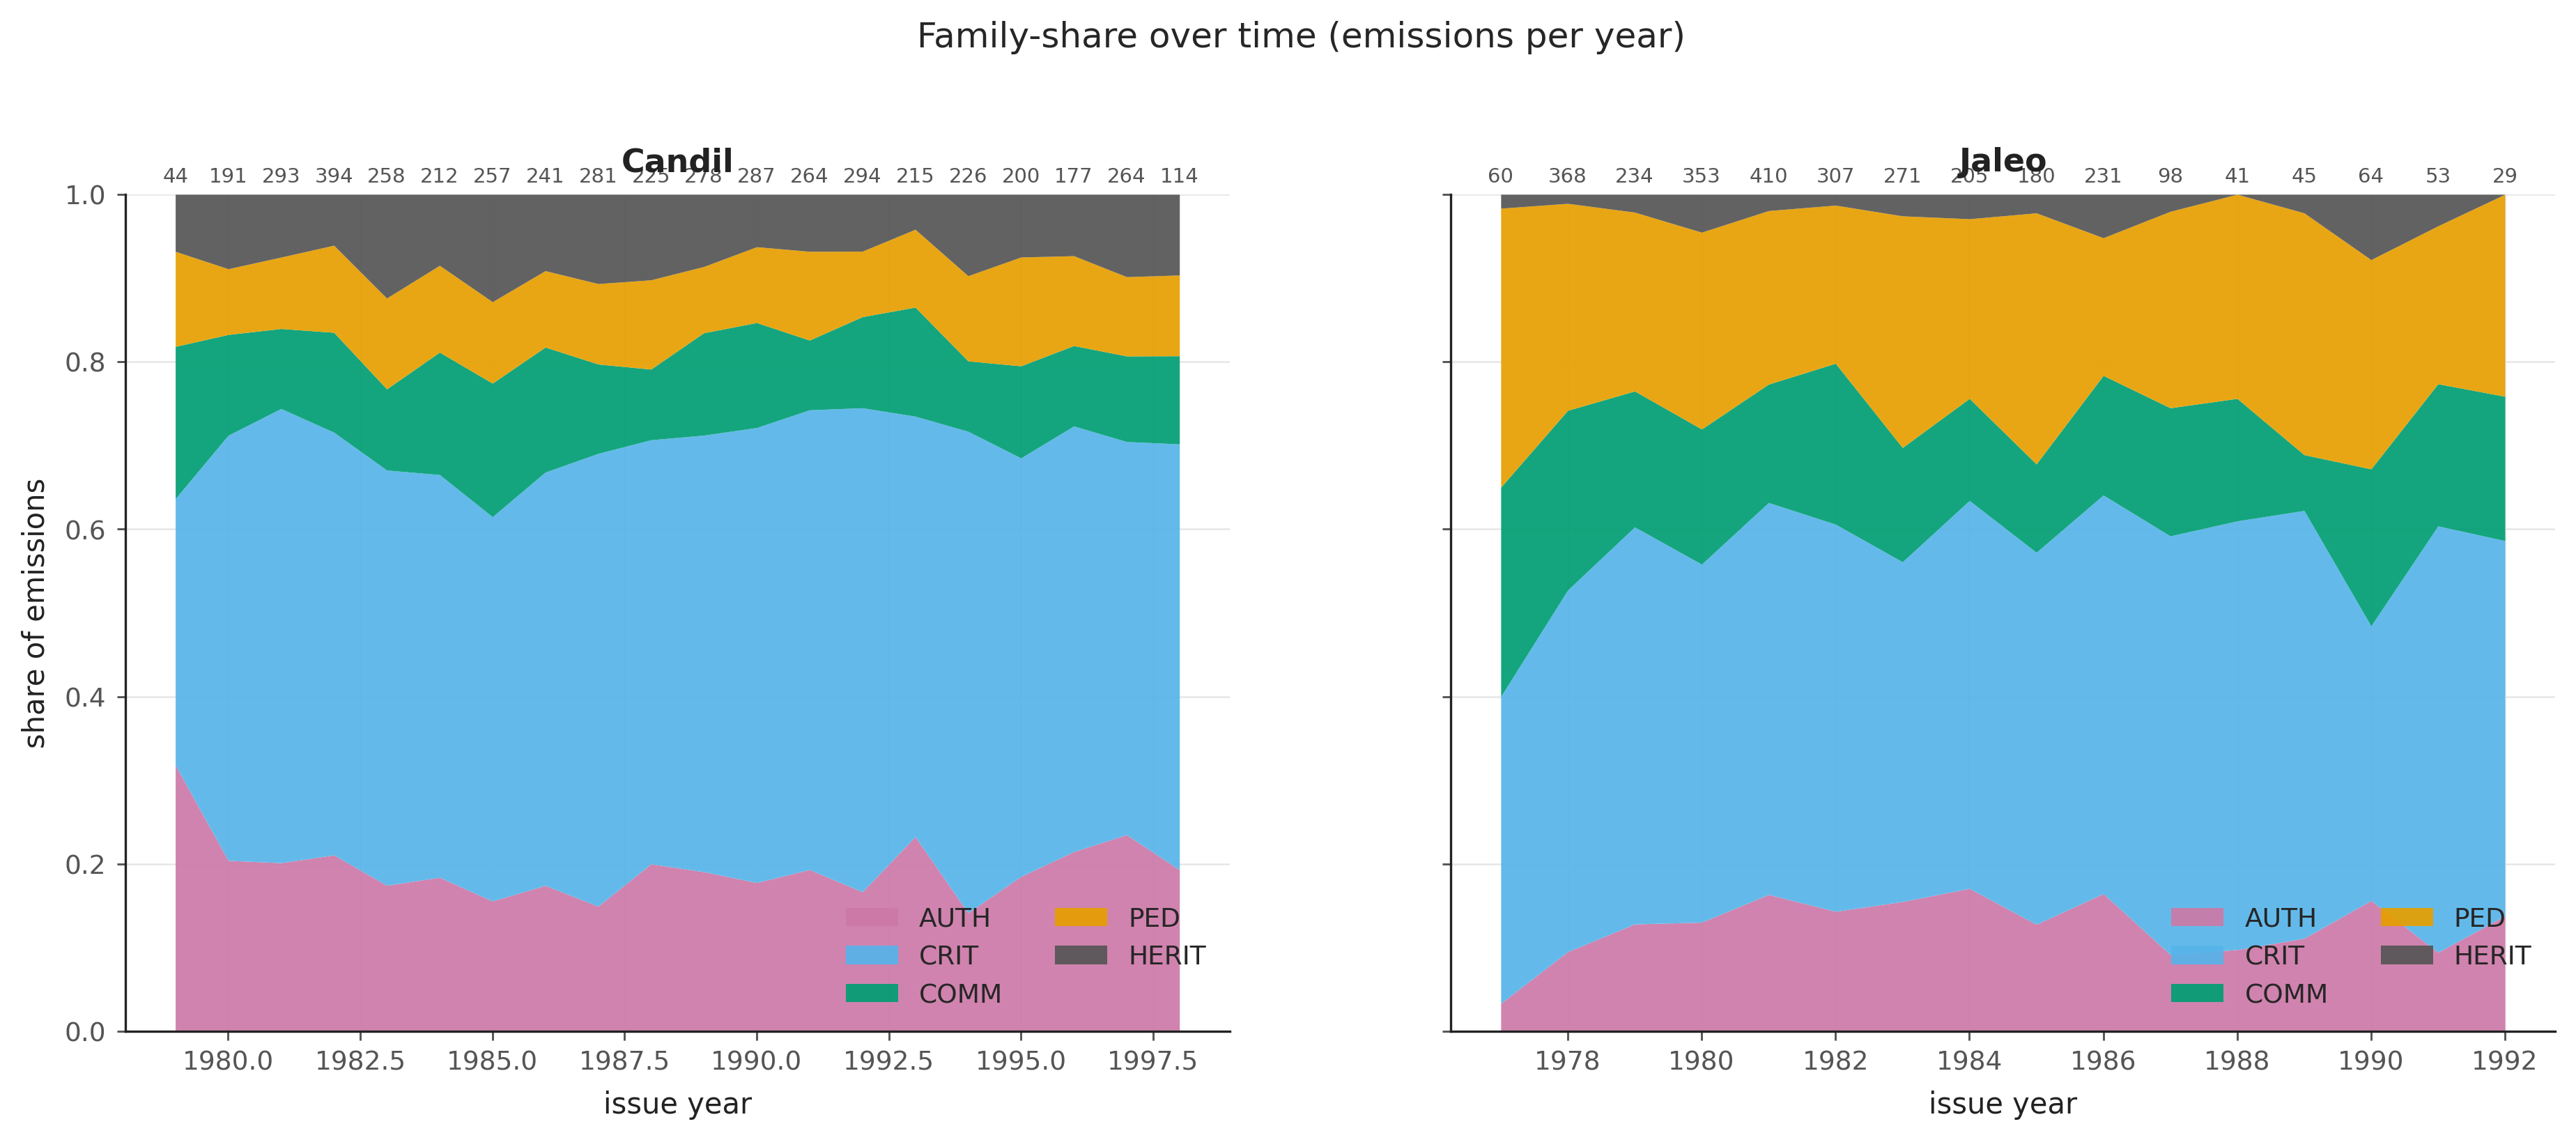

In [10]:
show('plot_10_possible_top_codes', 'top considered-but-not-emitted codes')
show('plot_11_emit_vs_possible', 'emit vs. possible per code')
show('plot_12_rationale_length', 'rationale/evidence length by confidence')
show('plot_13_target_top_terms', 'top target terms per family')
show('plot_14_temporal_family', 'family share over time')

## 4. Authenticity deep dive

**plot_15_auth_internal_overlap** -- within-article overlap among AUTH subtypes

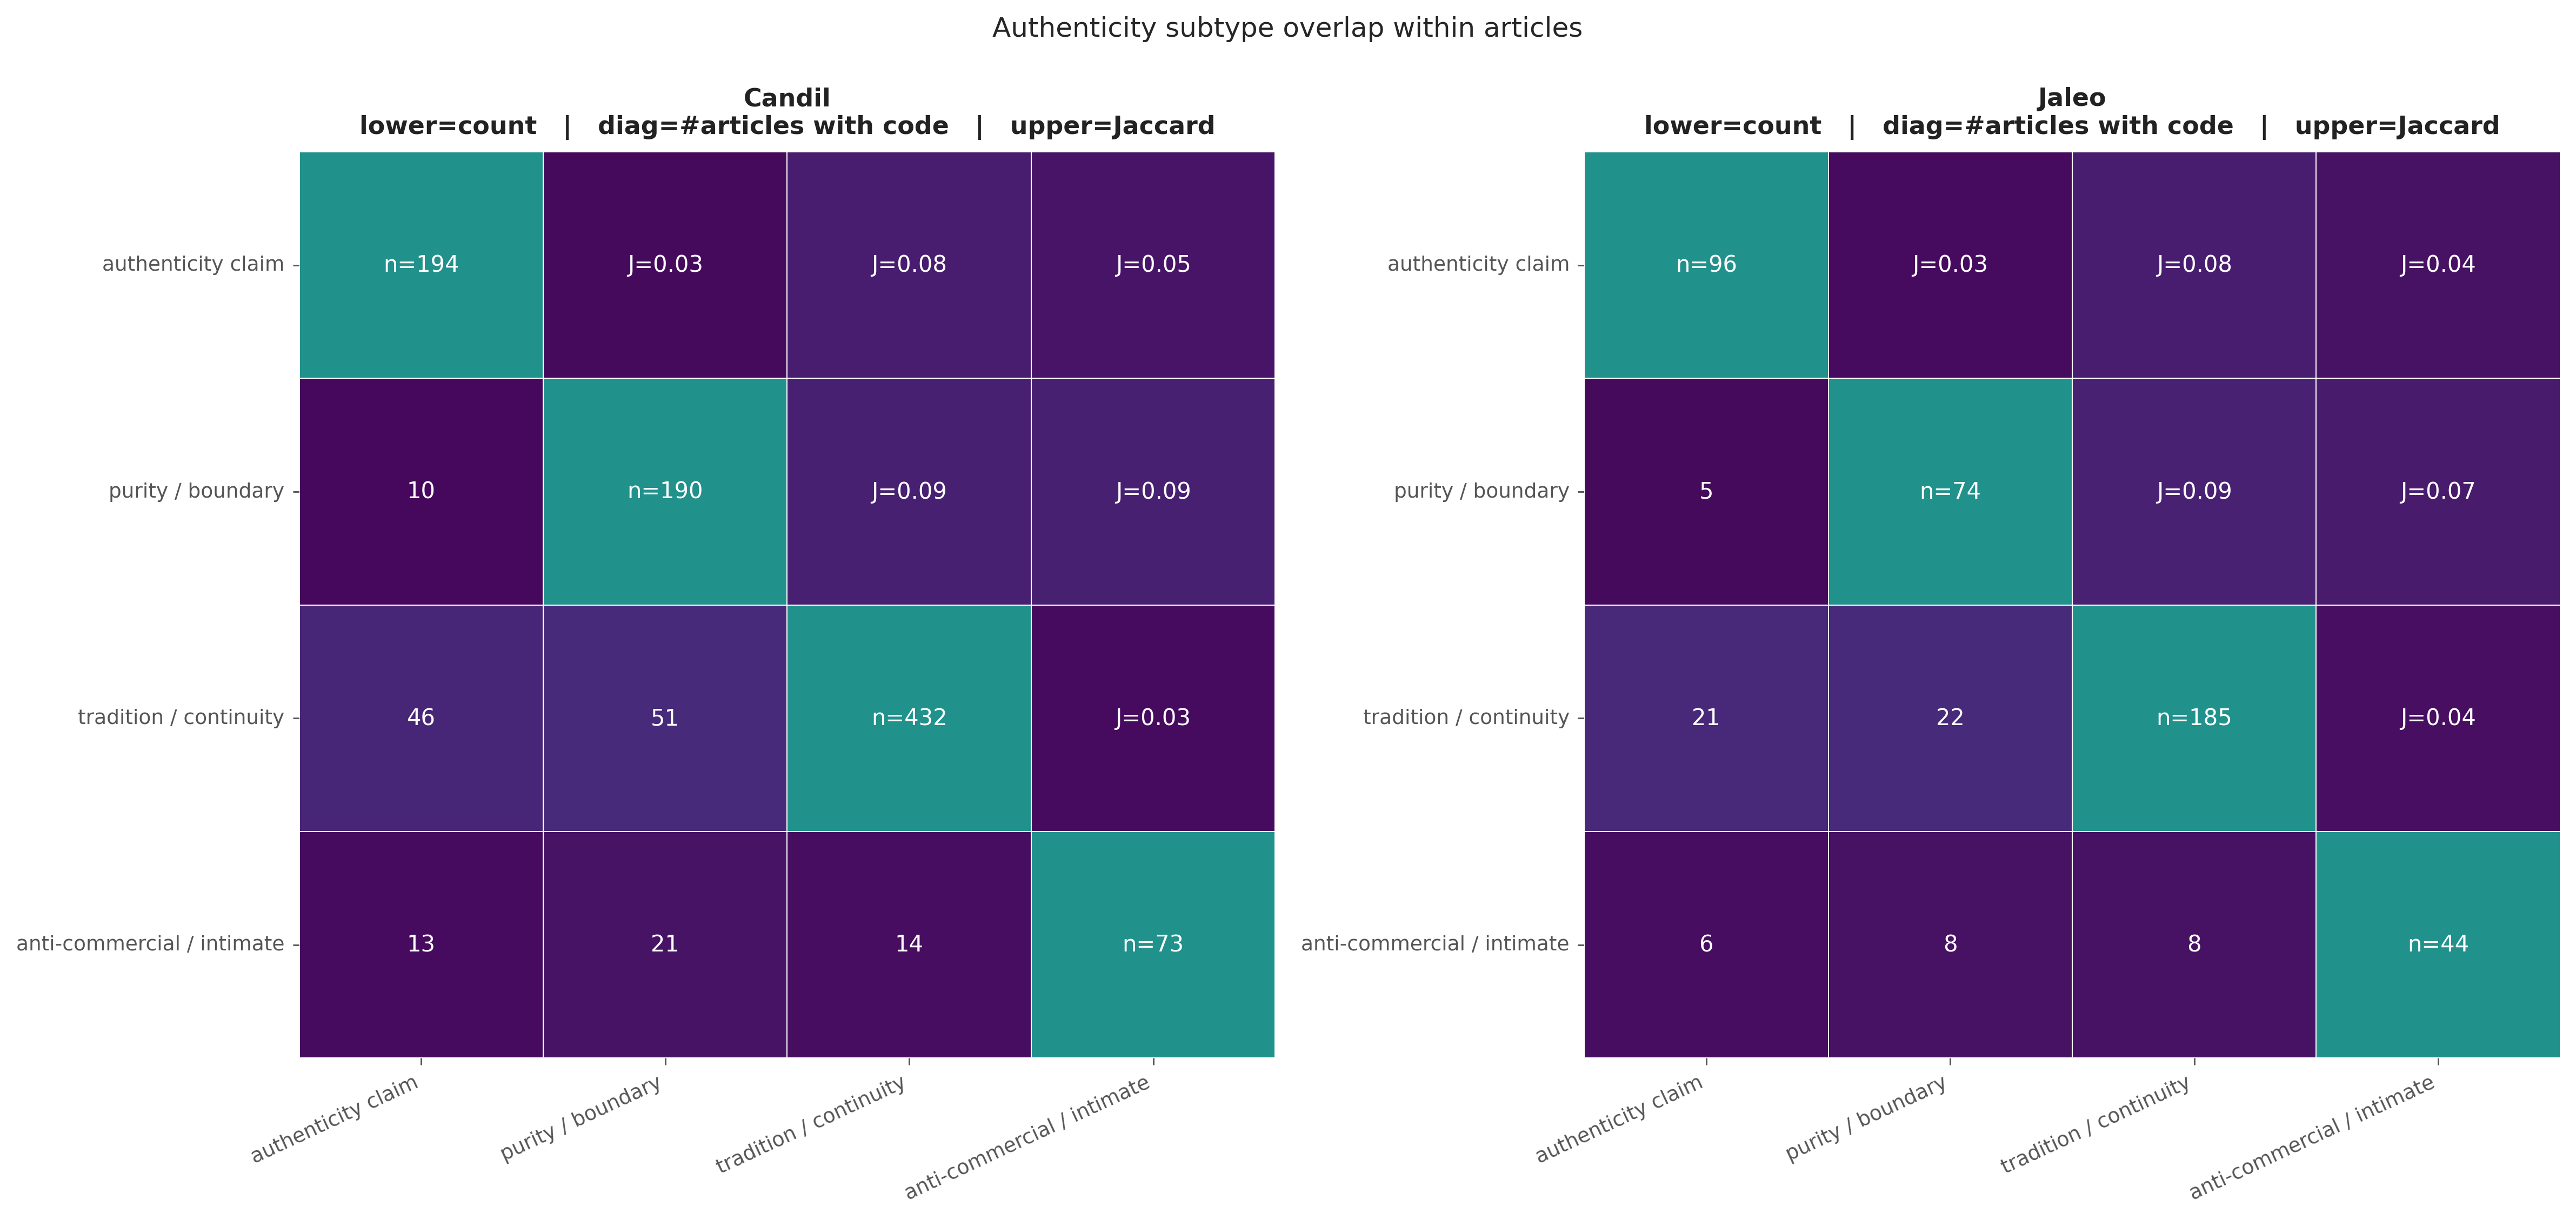

**plot_16_auth_family_overlap** -- AUTH x other-family overlap

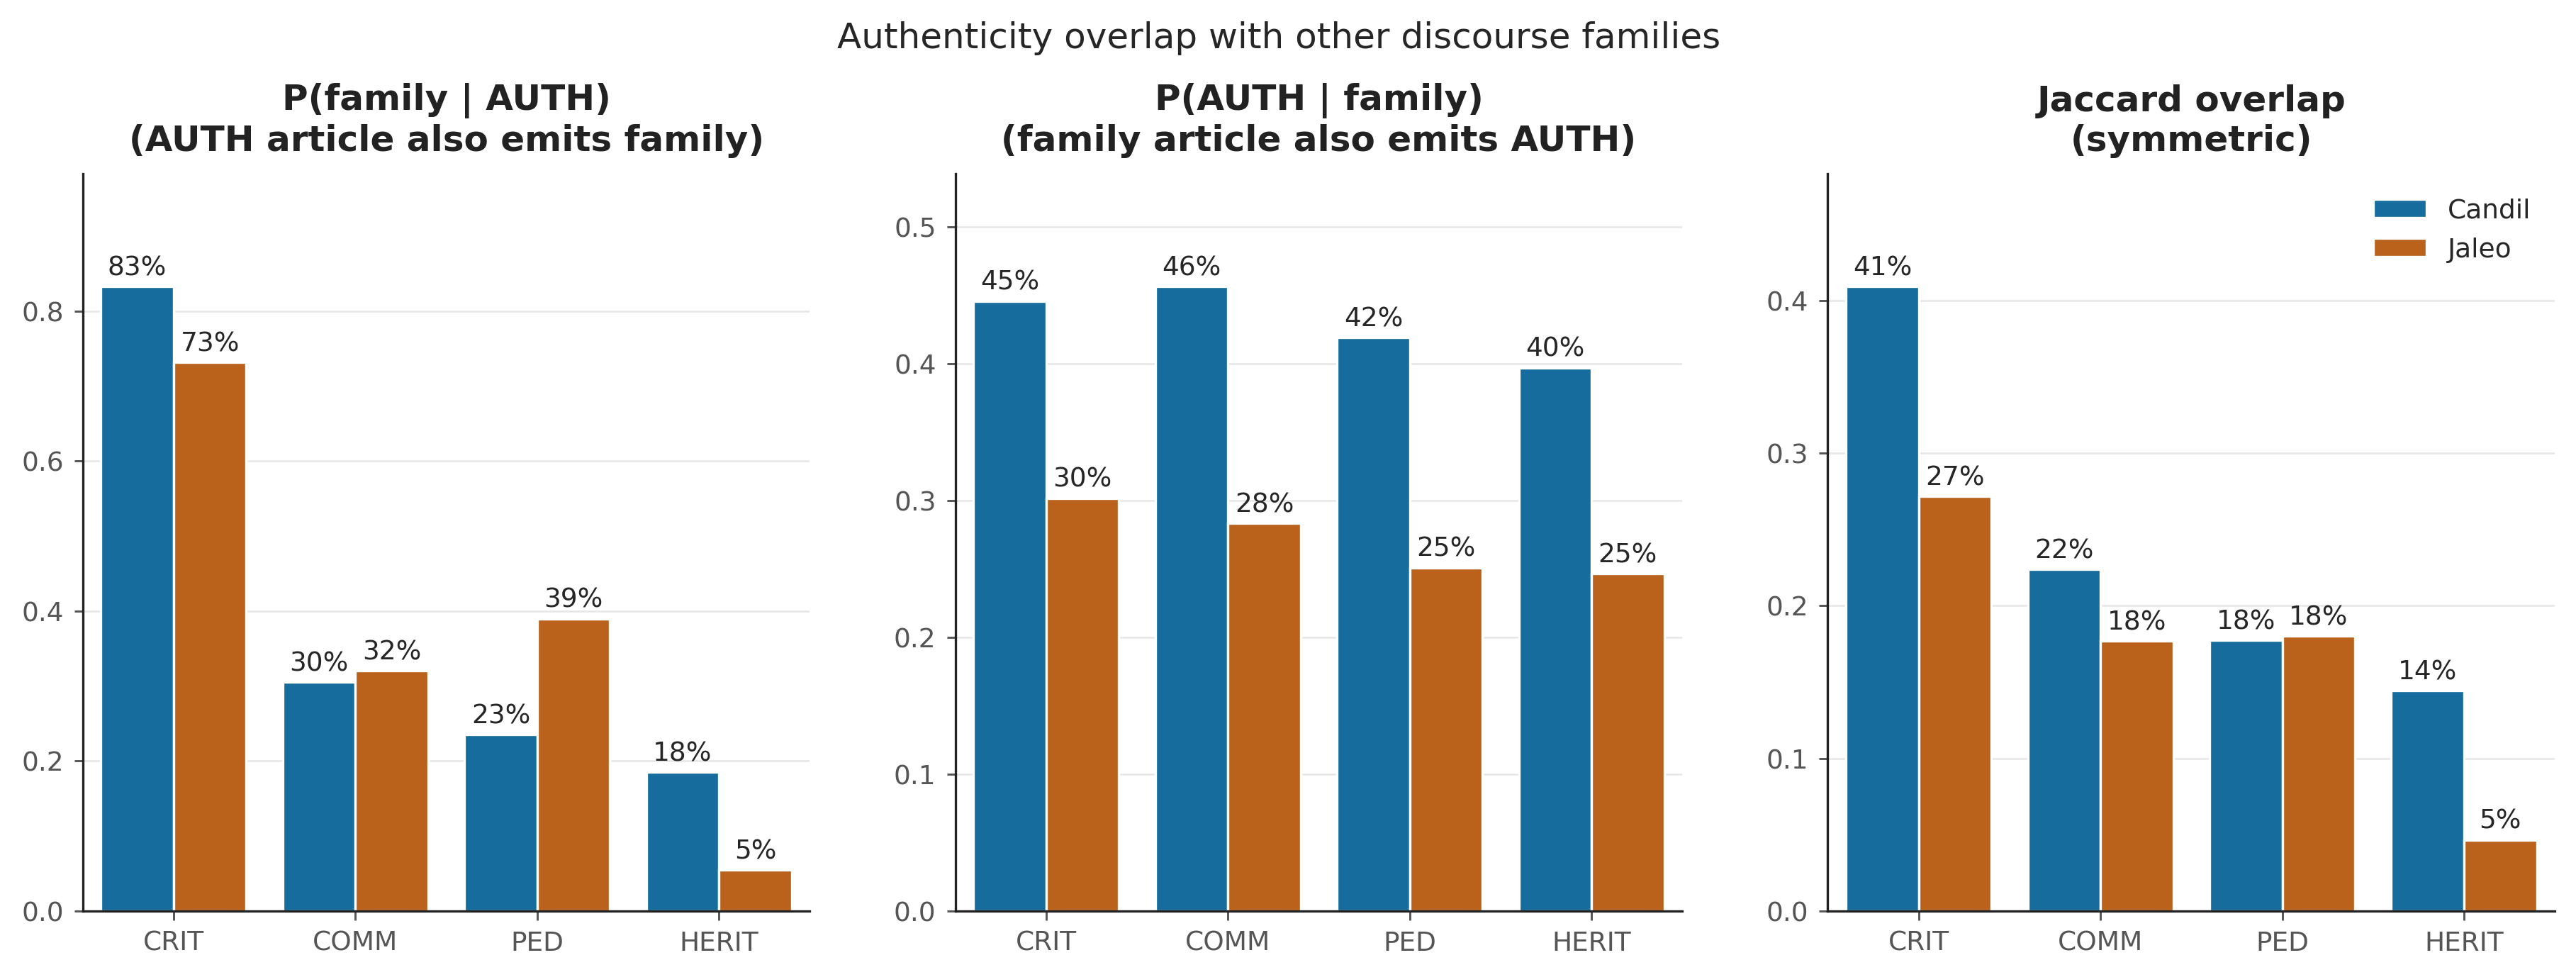

**plot_17_auth_target_terms** -- top target terms per AUTH subcode

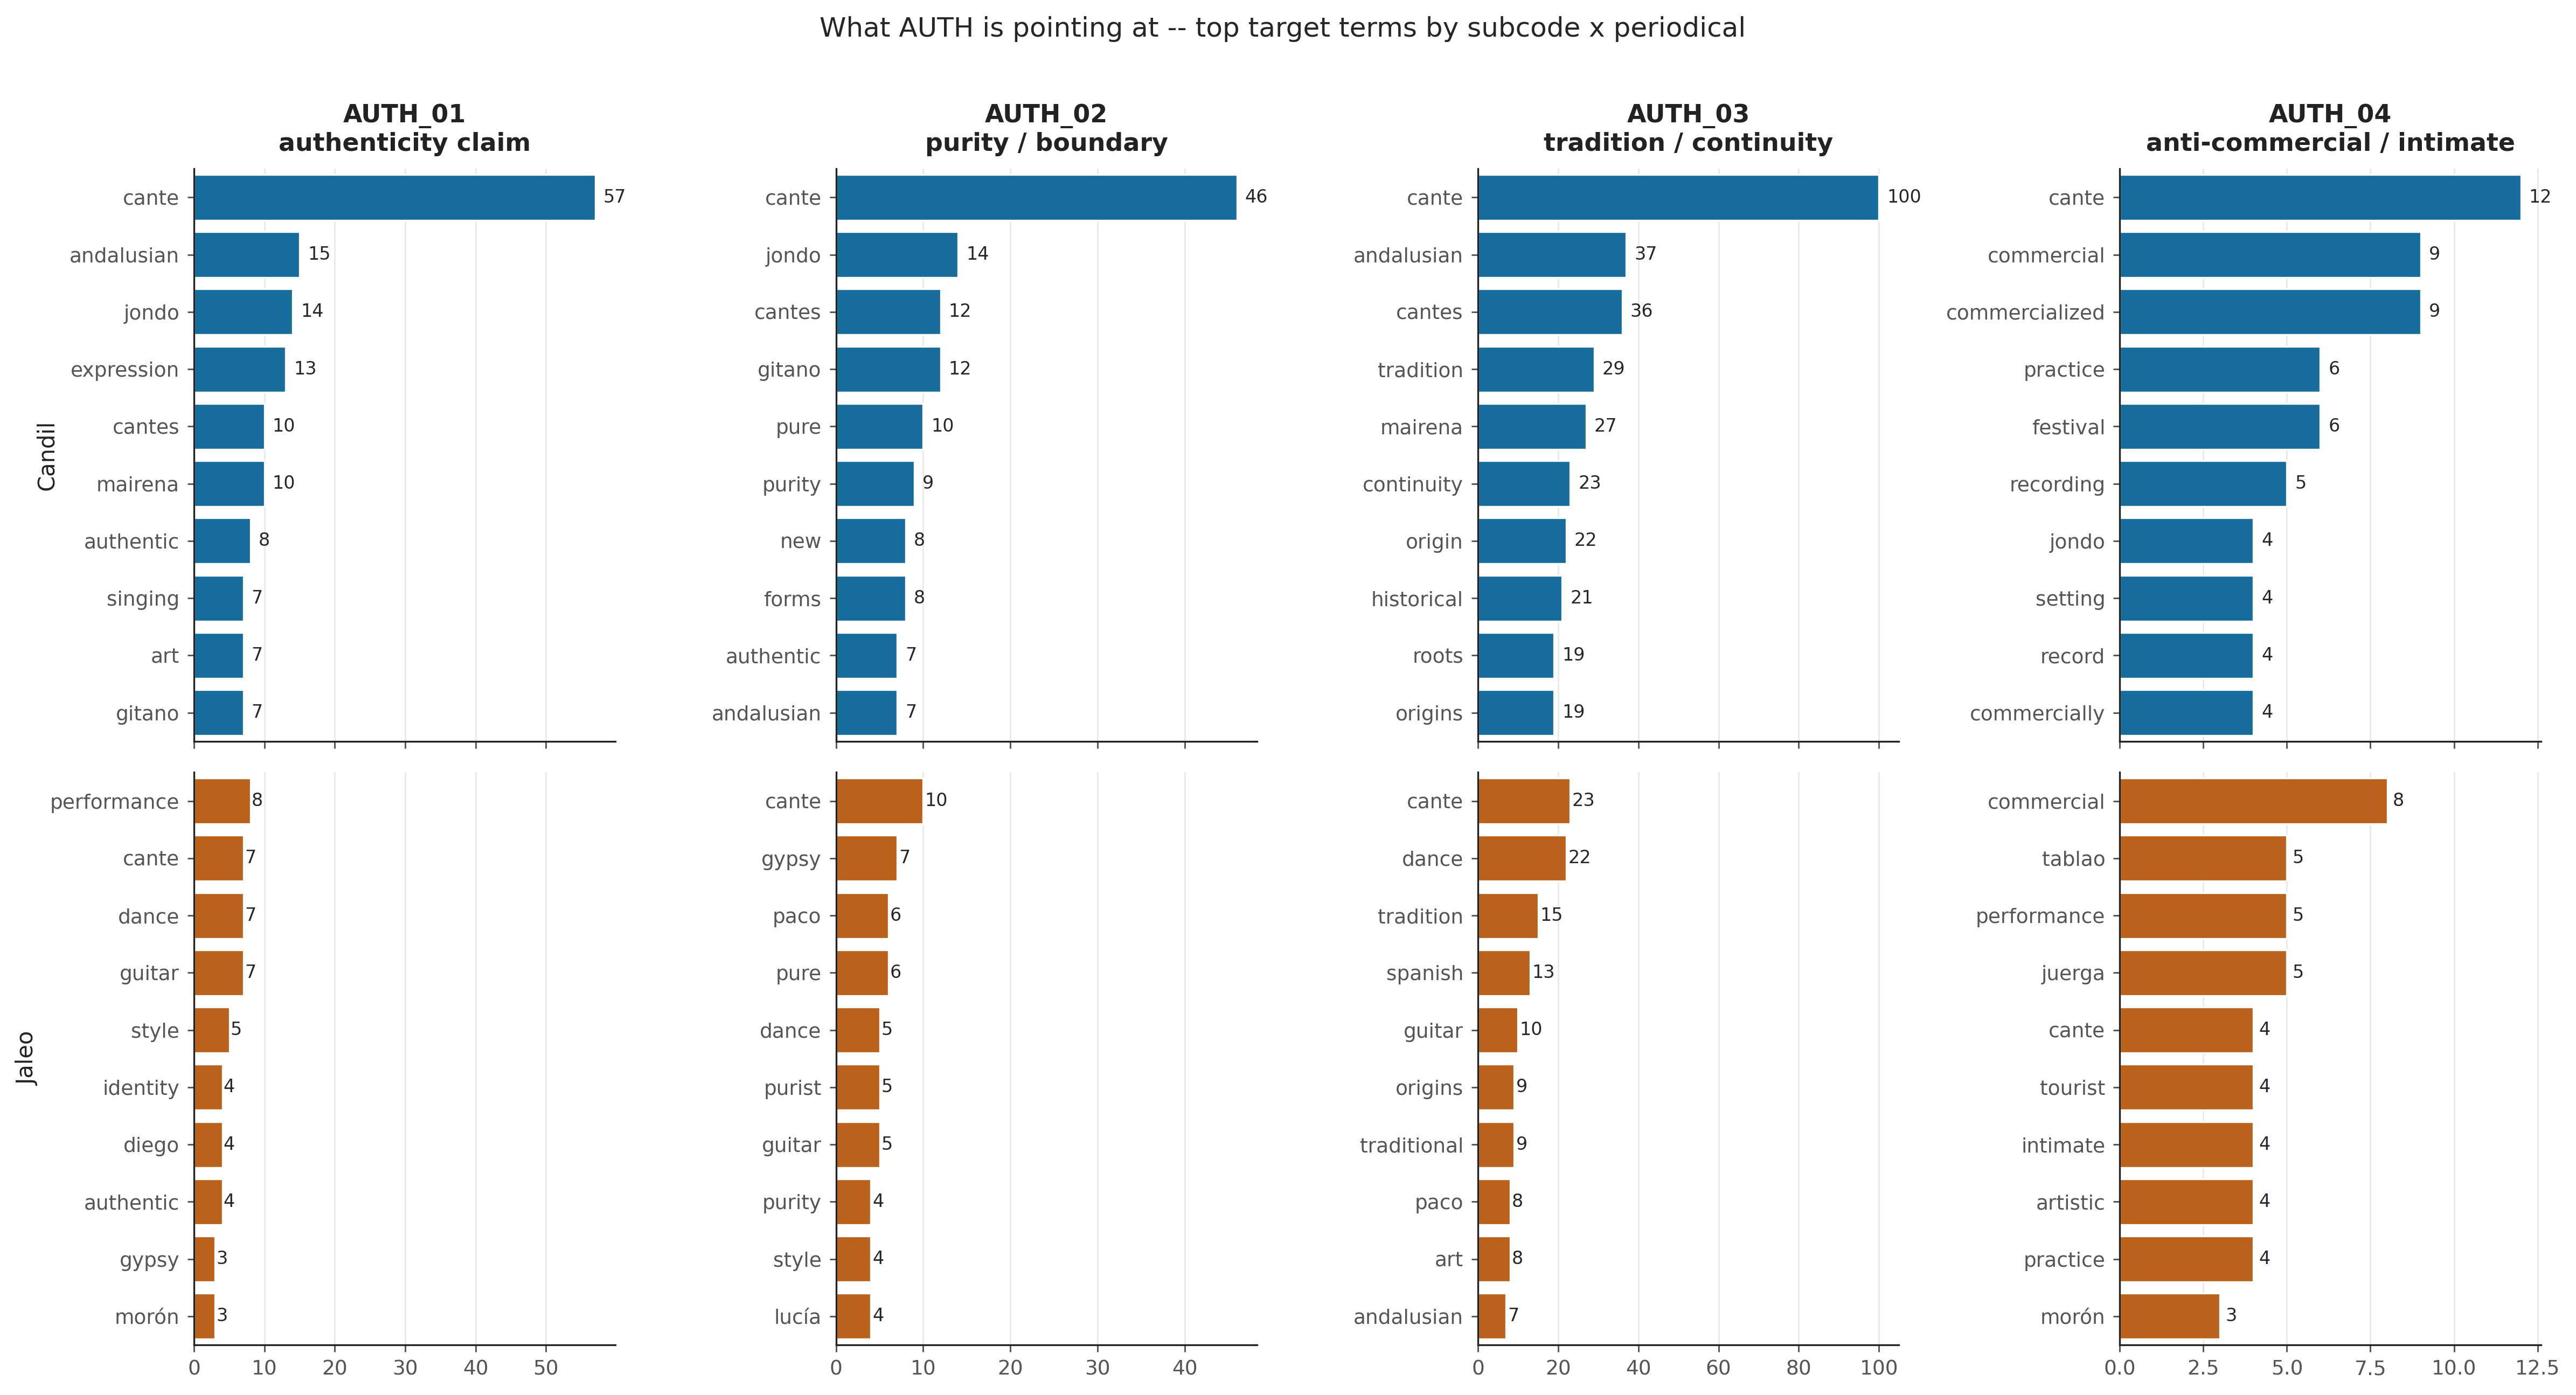

**plot_18_auth_polarity_boundaries** -- polarity & boundary signals when AUTH present

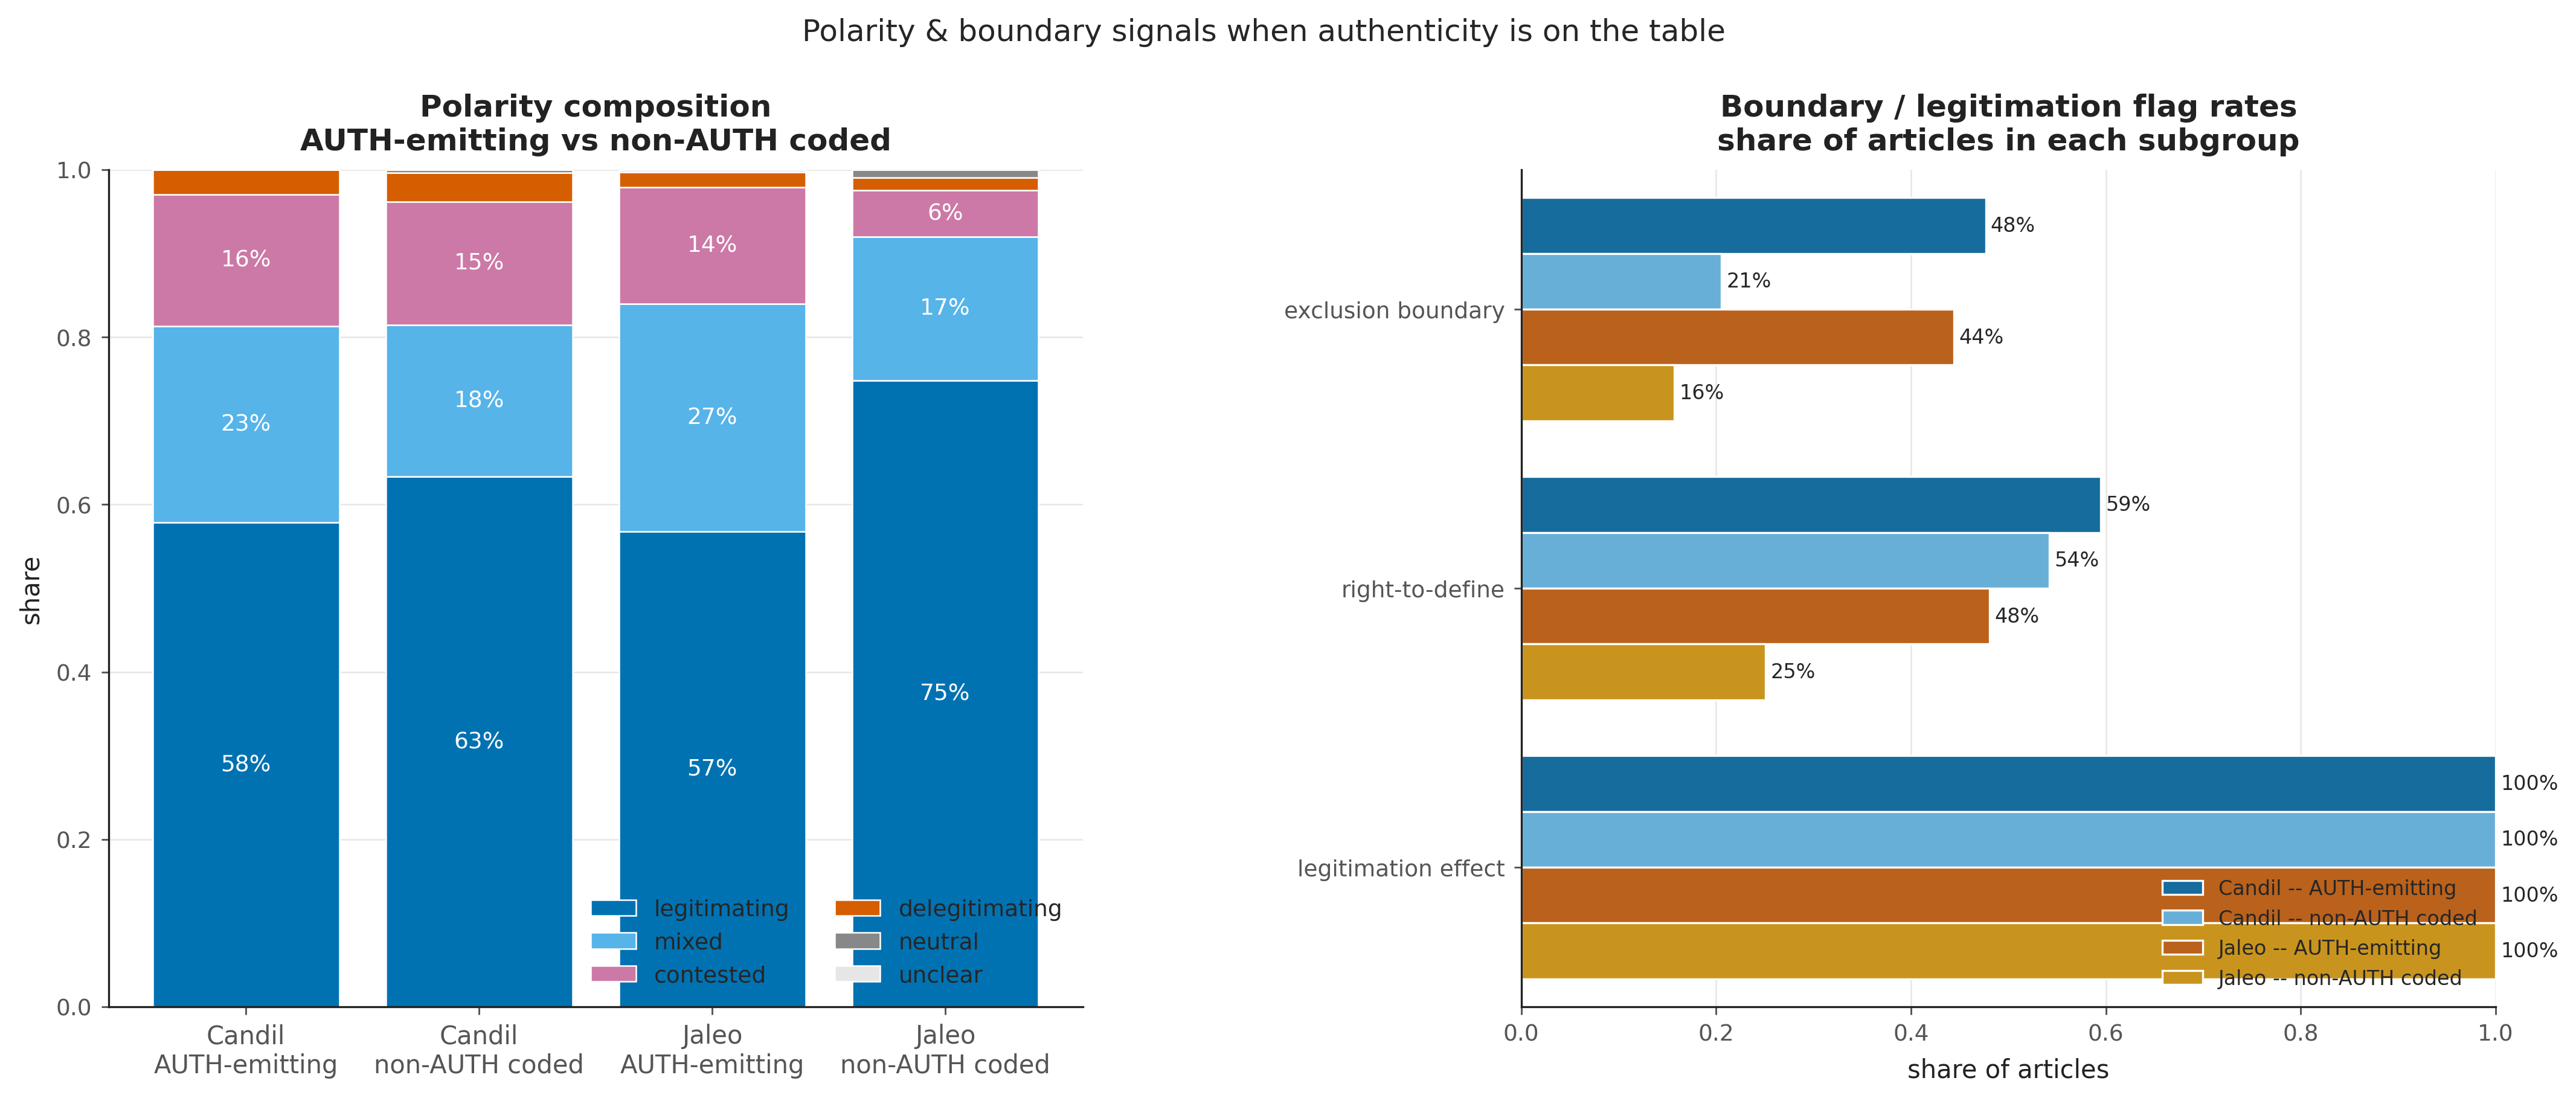

**plot_19_auth_temporal** -- AUTH share and subtype mix over time

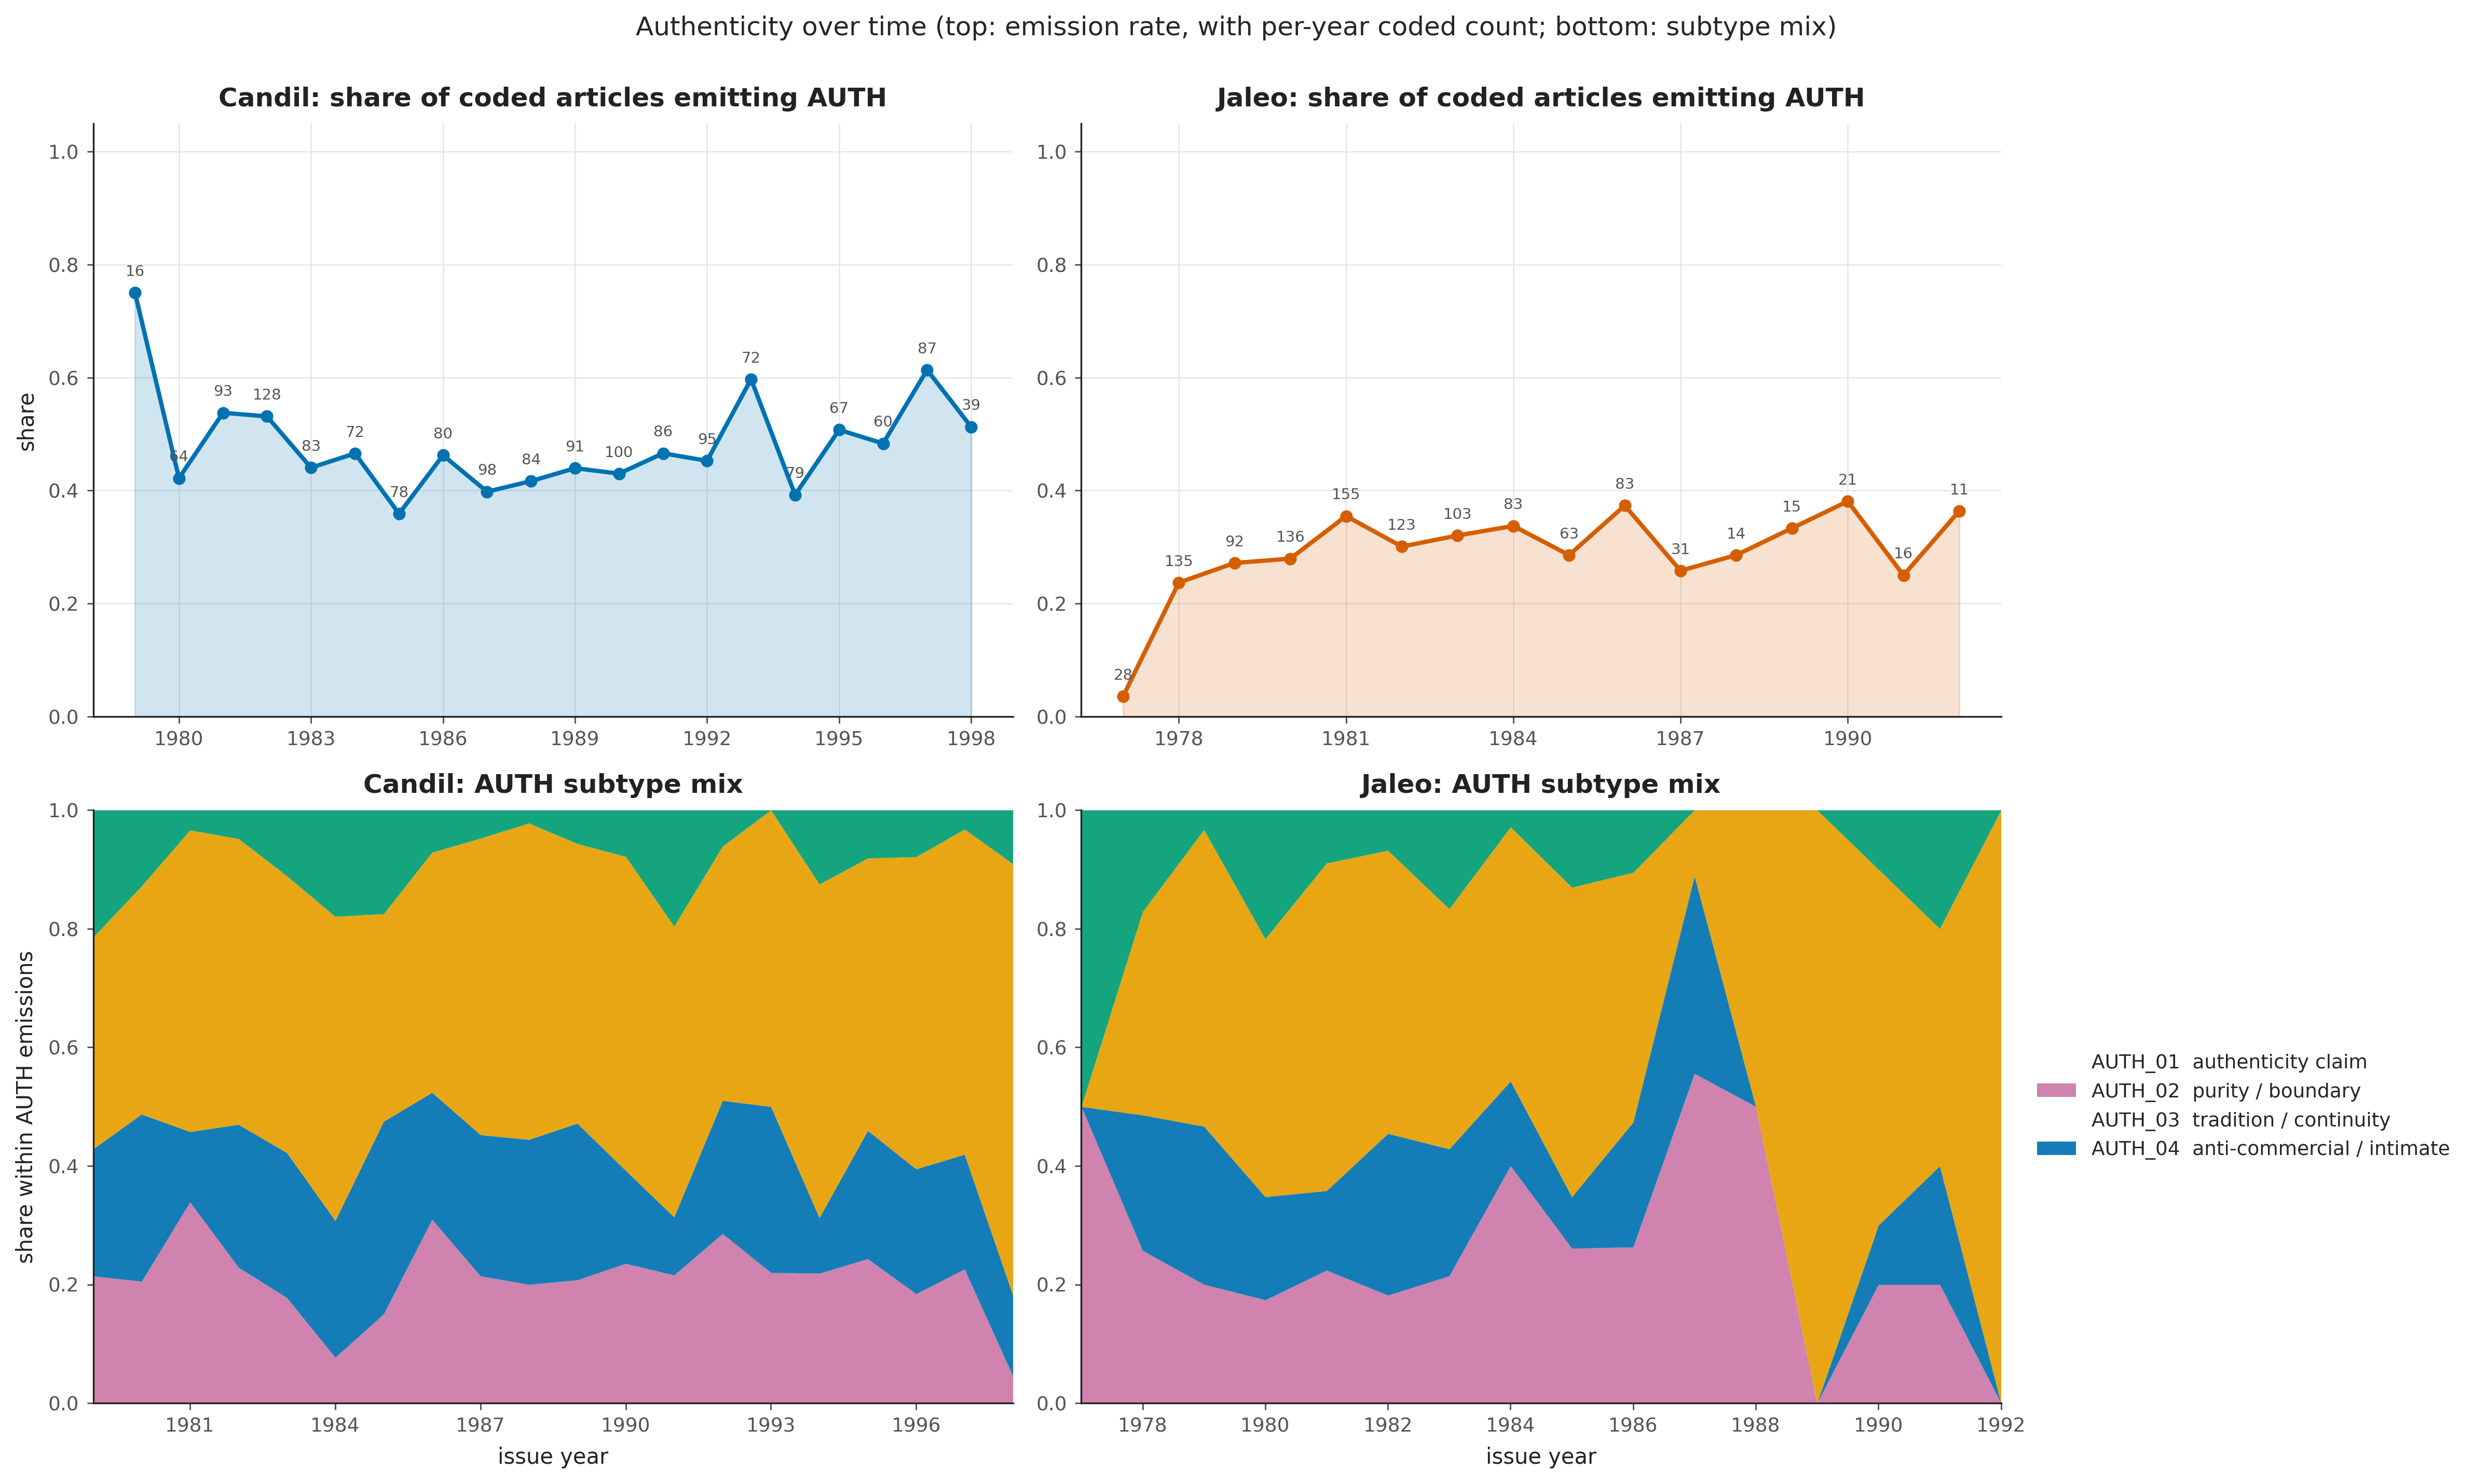

**plot_20_auth_emit_vs_possible** -- AUTH near-miss vs emission per subcode

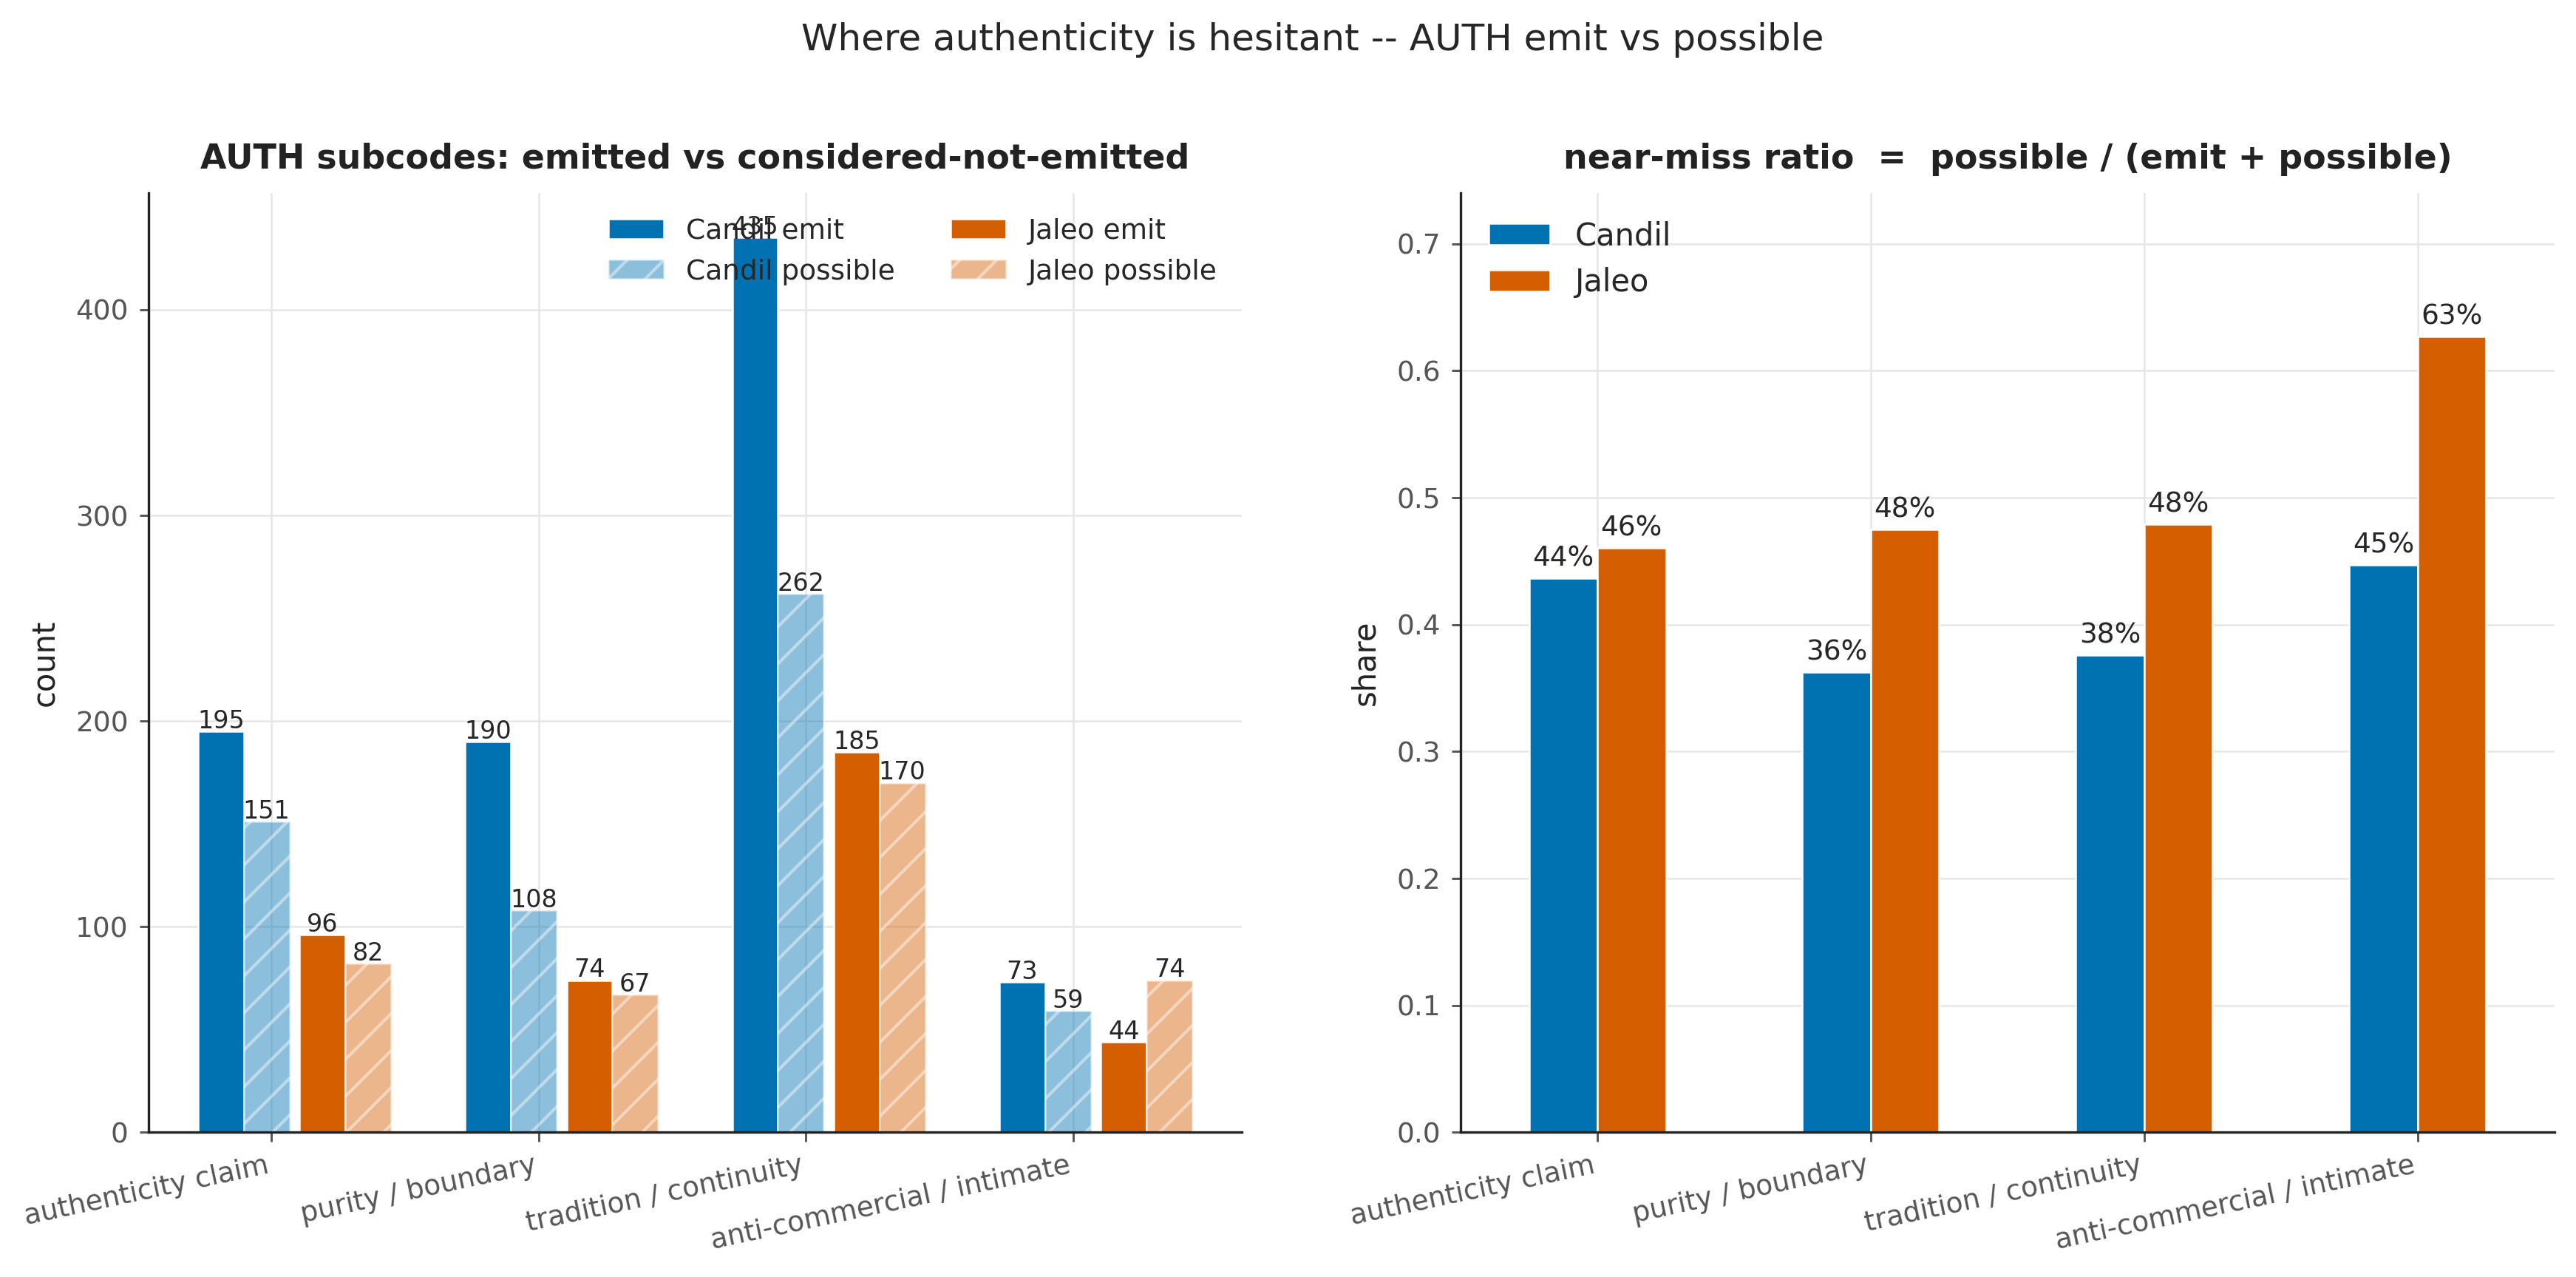

In [11]:
show('plot_15_auth_internal_overlap', 'within-article overlap among AUTH subtypes')
show('plot_16_auth_family_overlap', 'AUTH x other-family overlap')
show('plot_17_auth_target_terms', 'top target terms per AUTH subcode')
show('plot_18_auth_polarity_boundaries', 'polarity & boundary signals when AUTH present')
show('plot_19_auth_temporal', 'AUTH share and subtype mix over time')
show('plot_20_auth_emit_vs_possible', 'AUTH near-miss vs emission per subcode')